In [2]:
# ΚΕΛΙ 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import IPython.display as display

from sklearn.feature_selection import VarianceThreshold

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
# ΚΕΛΙ 2
folder_path = "data"
# Διαβάζει τον φάκελο data και φτιάχνει
# μια λίστα με τα ονόματα όλων των αρχείων που τελειώνουν σε .csv.
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

df_list = []

#Λούπα που μπαίνει σε κάθε αρχείο ξεχωριστά,
#το διαβάζει ως αυτόνομο DataFrame (pd.read_csv) και το αποθηκεύει προσωρινά στη λίστα df_list.
for file in files:
    temp_df = pd.read_csv(os.path.join(folder_path, file))
    df_list.append(temp_df)

#Το πιο σημαντικό βήμα. Παίρνει όλα τα ξεχωριστά DataFrames από τη λίστα
#και τα «κολλάει» το ένα κάτω από το άλλο (κάθετα), δημιουργώντας ένα τεράστιο, ενιαίο DataFrame df.
#Το ignore_index=True επαναφέρει την αρίθμηση των γραμμών από το 0 έως το σύνολο όλων των γραμμών,
#ώστε να μην υπάρχουν διπλοί δείκτες (indexes).
df = pd.concat(df_list, ignore_index=True)

#Αφαιρεί τυχόν κρυφούς αρχικούς ή τελικούς κενούς χώρους (spaces) από τα ονόματα των στηλών.
df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# ΚΕΛΙ 3 - Πλήρης Εμφάνιση Όλων των Στηλών σε Διαδραστικό Πίνακα
print(f" ΔΙΑΣΤΑΣΕΙΣ DATASET: {df.shape[0]:,} γραμμές | {df.shape[1]} στήλες")

# Ρύθμιση Pandas για απεριορίστα rows στην HTML εμφάνιση
pd.set_option('display.max_rows', None)

# Δημιουργία του πίνακα
all_features = pd.DataFrame({
    'Α/Α': range(1, len(df.columns) + 1),
    'Όνομα Χαρακτηριστικού (Column Name)': df.columns,
    'Τύπος Δεδομένων (Dtype)': df.dtypes.values
})

# Εμφάνιση ως κανονικός πίνακας Jupyter (HTML DataFrame) αντί για απλό print string
display.display(all_features.style.hide(axis='index'))

# Επαναφορά ρυθμίσεων
pd.reset_option('display.max_rows')

memory_gb = df.memory_usage(deep=True).sum() / (1024**3)
print(f" Συνολική Χρήση Μνήμης RAM: {memory_gb:.2f} GB")

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")
print("\nData Types:\n")
print(df.dtypes.value_counts())

 ΔΙΑΣΤΑΣΕΙΣ DATASET: 2,830,743 γραμμές | 79 στήλες


Α/Α,Όνομα Χαρακτηριστικού (Column Name),Τύπος Δεδομένων (Dtype)
1,Destination Port,int64
2,Flow Duration,int64
3,Total Fwd Packets,int64
4,Total Backward Packets,int64
5,Total Length of Fwd Packets,int64
6,Total Length of Bwd Packets,int64
7,Fwd Packet Length Max,int64
8,Fwd Packet Length Min,int64
9,Fwd Packet Length Mean,float64
10,Fwd Packet Length Std,float64


 Συνολική Χρήση Μνήμης RAM: 1.68 GB
Dataset shape: (2830743, 79)
Number of features: 79
Number of samples: 2830743

Data Types:

int64      54
float64    24
str         1
Name: count, dtype: int64


Το σύνολο δεδομένων CIC-IDS2017 αποτελείται από μεγάλο αριθμό δικτυακών ροών (network flows) και περιλαμβάνει χαρακτηριστικά που περιγράφουν τη συμπεριφορά της δικτυακής κίνησης.

Το dataset περιέχει:
- αριθμητικά χαρακτηριστικά (numerical features),
- χαρακτηριστικά που σχετίζονται με πακέτα και χρονικές καθυστερήσεις,
- στατιστικά χαρακτηριστικά ροών,
- καθώς και τη μεταβλητή στόχο (Label), η οποία υποδεικνύει τον τύπο της δικτυακής δραστηριότητας.

Ωστόσο παρά τον μεγάλο όγκο, τα χαρακτηριστικά μπορούν να ομαδοποιηθούν ανάλογα με τη λειτουργία και τη σημασία τους.

1) **Identification Features**
Source IP         Διεύθυνση IP αποστολέα
Destination IP    Διεύθυνση IP παραλήπτη
Source Port	      Θύρα προέλευσης
Destination Port  Θύρα προορισμού
Protocol          Πρωτόκολλο επικοινωνίας
Τα χαρακτηριστικά αυτά χρησιμοποιούνται για την αναγνώριση της δικτυακής ροής και βοηθούν στην αναγνώριση της προέλευσης και του προορισμού της επικοινωνίας.

2) **Flow Features**
Flow Duration	Συνολική διάρκεια της ροής
Flow Bytes/s	Ρυθμός μεταφοράς bytes ανά δευτερόλεπτο
Flow Packets/s	Ρυθμός πακέτων ανά δευτερόλεπτο
Τα χαρακτηριστικά αυτά χρησιμοποιούνται συχνά για την ανίχνευση ασυνήθιστης ή κακόβουλης δραστηριότητας.

3) **Packet Length Features**
Total Length of Fwd Packets	 Συνολικό μήκος forward packets
Packet Length Mean	         Μέσο μήκος πακέτων
Packet Length Std	         Τυπική απόκλιση μήκους πακέτων
Max Packet Length	         Μέγιστο μέγεθος πακέτου
Αφορούν το μέγεθος των πακέτων που ανταλλάσσονται. Μεγάλη μεταβλητότητα στα packet lengths μπορεί να σχετίζεται με επιθέσεις ή μη φυσιολογική κίνηση.

4) **Inter-Arrival Time (IAT) Features**
Flow IAT Mean	Μέσο χρονικό διάστημα μεταξύ πακέτων
Flow IAT Std	Τυπική απόκλιση χρονικών διαστημάτων
Fwd IAT Total	Συνολικός χρόνος καθυστέρησης forward πακέτων
Τα χαρακτηριστικά αυτά περιγράφουν τα χρονικά διαστήματα μεταξύ διαδοχικών πακέτων.
Οι χρονικές καθυστερήσεις μπορούν να αποκαλύψουν συγκεκριμένα πρότυπα επιθέσεων.

5) **TCP Flag Features**
SYN Flag Count	Αριθμός SYN flags
ACK Flag Count	Αριθμός ACK flags
FIN Flag Count	Αριθμός FIN flags
RST Flag Count	Αριθμός RST flags
Αφορούν TCP control flags. Η συχνότητα εμφάνισης των flags μπορεί να βοηθήσει στον εντοπισμό επιθέσεων όπως SYN Flood.

6) **Active / Idle Features**
Active Mean	 Μέση διάρκεια ενεργής κατάστασης
Idle Mean	 Μέση διάρκεια αδράνειας
Περιγράφουν περιόδους δραστηριότητας και αδράνειας της σύνδεσης. Τα χαρακτηριστικά αυτά είναι χρήσιμα για τη διάκριση φυσιολογικής και αυτοματοποιημένης δικτυακής συμπεριφοράς.

7) **Μεταβλητή Στόχος (Label)**
Η στήλη Label αποτελεί τη μεταβλητή στόχο του dataset και περιγράφει τον τύπο της δικτυακής δραστηριότητας.
Οι τιμές της περιλαμβάνουν:
φυσιολογική δικτυακή κίνηση (BENIGN),
καθώς και διαφορετικές κατηγορίες κυβερνοεπιθέσεων.
Η ανάλυση της κατανομής της μεταβλητής στόχου είναι ιδιαίτερα σημαντική, καθώς πιθανή ανισορροπία κλάσεων μπορεί να επηρεάσει σημαντικά την απόδοση των μοντέλων μηχανικής μάθησης.

In [5]:
# ΚΕΛΙ 4 
# Έλεγχος για Missing Values και Duplicates
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())



Total Missing Values:
1358

Duplicate Rows:
308381


In [6]:
# ΚΕΛΙ 5
# Remove duplicates
df.drop_duplicates(inplace=True)

# Replace inf values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("Final Shape After Cleaning:", df.shape)

Final Shape After Cleaning: (2520798, 79)


Διαχείριση και Αιτιολόγηση Καθαρισμού Δεδομένων
1. Τεχνική drop_duplicates: Επιλέχθηκε η άμεση διαγραφή των διπλότυπων αντί για τη διατήρησή τους, καθώς οι πανομοιότυπες εγγραφές στο ίδιο microsecond αποτελούν πλεονασμό του συστήματος καταγραφής. Η αφαίρεσή τους είναι η μοναδική λύση για τον πλήρη αποκλεισμό του Data Leakage.

2. Τεχνική replace για inf τιμές: Οι άπειρες τιμές (inf), που προκύπτουν από διαιρέσεις με το μηδέν 
(π.χ. σε ροές με μηδενική διάρκεια), μετατράπηκαν σε ελλιπείς τιμές (NaN) και στη συνέχεια αφαιρέθηκαν , καθώς η παρουσία τους θα προκαλεί σφάλματα (errors) κατά την εκτέλεση των μαθηματικών αλγορίθμων μηχανικής μάθησης στη συνέχεια.

3. Τεχνική dropna NaN: Επιλέχθηκε η πλήρης αφαίρεση των γραμμών αυτών αντί για τεχνικές συμπλήρωσης (όπως interpolation ή μέσος όρος). Η συμπλήρωση με τεχνητές τιμές σε δικτυακές ροές θα εισήγαγε πλασματικά δεδομένα που θα αλλοίωναν τα πραγματικά χαρακτηριστικά των επιθέσεων
(ειδικά αν μια γραμμή ήταν ενδιάμεσα μιας benign και μιας ddos), ενώ η αφαίρεσή τους είναι ασφαλής λόγω του ελάχιστου πλήθους τους στο dataset.

In [7]:
# ΚΕΛΙ 6 - Πλήρης Στατιστική Περιγραφή σε Διαδραστικό Πίνακα

print(" ΥΠΟΛΟΓΙΣΜΟΣ ΣΥΓΚΕΝΤΡΩΤΙΚΩΝ ΣΤΑΤΙΣΤΙΚΩΝ ΜΕΓΕΘΩΝ")

# Ρύθμιση Pandas ώστε να εμφανίσει όλες τις 78 γραμμές των στατιστικών
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Υπολογισμός των στατιστικών και αναστροφή (Transpose)
stats = df.describe().T

# Στρογγυλοποίηση των δεκαδικών σε 2 ψηφία για να μην βγαίνουν scientific notations (e+03 κλπ)
stats = stats.round(2)

# Εμφάνιση ως κανονικός πίνακας Jupyter (HTML DataFrame)
display.display(stats)

# Επαναφορά αρχικών ρυθμίσεων
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

 ΥΠΟΛΟΓΙΣΜΟΣ ΣΥΓΚΕΝΤΡΩΤΙΚΩΝ ΣΤΑΤΙΣΤΙΚΩΝ ΜΕΓΕΘΩΝ


,count,mean,std,min,25%,50%,75%,max
Destination Port,2520798.0,8690.59,19012.80,0.000000e+00,53.00,80.00,443.00,6.553500e+04
Flow Duration,2520798.0,16591611.46,35232762.93,-1.300000e+01,208.00,50622.00,5333340.50,1.200000e+08
Total Fwd Packets,2520798.0,10.28,794.42,1.000000e+00,2.00,2.00,6.00,2.197590e+05
Total Backward Packets,2520798.0,11.57,1056.92,0.000000e+00,1.00,2.00,5.00,2.919220e+05
Total Length of Fwd Packets,2520798.0,611.95,10588.27,0.000000e+00,12.00,66.00,332.00,1.290000e+07
Total Length of Bwd Packets,2520798.0,18144.40,2398177.40,0.000000e+00,6.00,156.00,997.00,6.554530e+08
Fwd Packet Length Max,2520798.0,231.23,756.38,0.000000e+00,6.00,40.00,202.00,2.482000e+04
Fwd Packet Length Min,2520798.0,19.20,60.80,0.000000e+00,0.00,2.00,37.00,2.325000e+03
Fwd Packet Length Mean,2520798.0,63.50,195.55,0.000000e+00,6.00,36.25,52.00,5.940860e+03
Fwd Packet Length Std,2520798.0,77.32,296.88,0.000000e+00,0.00,0.00,74.19,7.125600e+03


Στατιστική Περιγραφή και Ερμηνεία των Χαρακτηριστικών

Με την εφαρμογή της μεθόδου df.describe().T, υπολογίστηκαν τα βασικά συγκεντρωτικά στατιστικά μεγέθη (μέσος όρος, τυπική απόκλιση, ακραίες τιμές και τεταρτημόρια) για κάθε αριθμητική μεταβλητή. Από τη μελέτη του πλήρους πίνακα προκύπτουν τα εξής κύρια συμπεράσματα: 

1. Ύπαρξη Τεχνικών Σφαλμάτων (Data Bug): Π.χ. στη στήλη Flow Duration εντοπίστηκε ελάχιστη τιμή (min) ίση με -1.300000e+01. Επειδή η χρονική διάρκεια δεν μπορεί να είναι αρνητική, αυτό αποτελεί γνωστό πρόβλημα καταγραφής του εργαλείου CICFlowMeter λόγω προβλημάτων συγχρονισμού των πακέτων κατά τη διάρκεια έντονης δικτυακής συμφόρησης (π.χ. κατά τη διάρκεια επιθέσεων).

2. Έντονη Ασυμμετρία Κατανομών (Skewness): Σε χαρακτηριστικά όπως το Flow Duration, ο μέσος όρος
(mean = 16.591.610 μs) είναι εξαιρετικά μεγαλύτερος από τη διάμεσο (50% = 50.622 μs). Αυτό δείχνει ότι η πλειοψηφία των ροών ολοκληρώνεται σε κλάσματα του δευτερολέπτου, αλλά υπάρχει ένας μικρός αριθμός ροών με τεράστια διάρκεια (κοντά στο max) που παρασύρει τον μέσο όρο προς τα δεξιά.

3. Ανομοιογένεια στα Μεγέθη Πακέτων: Η πολύ υψηλή τυπική απόκλιση (std) σε μεταβλητές όπως το Packet Length Std και Max Packet Length δείχνει ότι το dataset περιλαμβάνει τόσο πολύ μικρά, επαναλαμβανόμενα πακέτα (χαρακτηριστικό αυτοματοποιημένων επιθέσεων ή scans) όσο και πολύ μεγάλα πακέτα (χαρακτηριστικό κανονικής μεταφοράς αρχείων/web browsing).

4. Κυριαρχία Υπηρεσιών Ιστού: Στη μεταβλητή Destination Port, τα τεταρτημόρια δείχνουν ότι το μεγαλύτερο μέρος της κίνησης συγκεντρώνεται στις θύρες 53, 80 και 443, κάτι που είναι απόλυτα αναμενόμενο για τη φυσιολογική λειτουργία ενός εταιρικού δικτύου.

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Duration


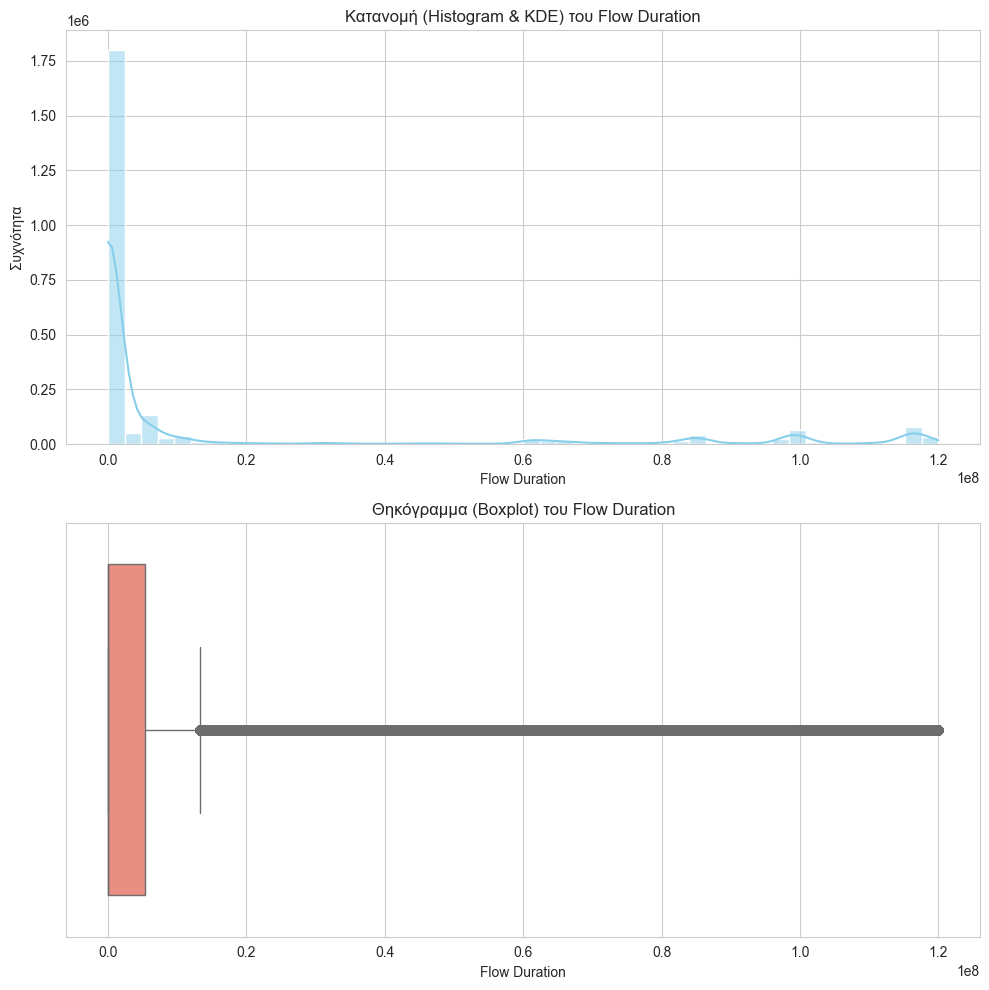

In [8]:
# ΚΕΛΙ 6.1 - Οπτικοποίηση για το Flow Duration (Κατακόρυφη Διάταξη)
print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Duration")

# Ορισμός: 2 γραμμές, 1 στήλη, μεγαλύτερο ύψος (10) για να είναι το ένα κάτω από το άλλο
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα / Διάγραμμα Πυκνότητας (Πρώτο γράφημα - πάνω)
sns.histplot(data=df, x='Flow Duration', kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή (Histogram & KDE) του Flow Duration')
axes[0].set_xlabel('Flow Duration')
axes[0].set_ylabel('Συχνότητα')
# axes[0].set_yscale('log') # Βγάλτε το '#' αν χρειαστεί λογαριθμική κλίμακα λόγω outliers

# 2. Θηκόγραμμα (Δεύτερο γράφημα - κάτω)
sns.boxplot(data=df, x='Flow Duration', ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Flow Duration')
axes[1].set_xlabel('Flow Duration')

# Αυτόματη διευθέτηση του χώρου ώστε να μην κρύβονται οι τίτλοι
plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Η κατανομή του χαρακτηριστικού "Flow Duration" εμφανίζει έντονη δεξιά ασυμμετρία, γεγονός που υποδηλώνει ότι η πλειονότητα των δικτυακών ροών έχει μικρή διάρκεια, ενώ ένας μικρός αριθμός ροών διαρκεί σημαντικά περισσότερο.

Η ύπαρξη ακραίων τιμών στο boxplot δείχνει την παρουσία εξαιρετικά μεγάλων συνδέσεων, οι οποίες ενδέχεται να σχετίζονται είτε με φυσιολογικές μεταφορές μεγάλου όγκου δεδομένων είτε με ύποπτη δικτυακή δραστηριότητα.

Η συγκεκριμένη συμπεριφορά είναι συνηθισμένη σε δεδομένα δικτυακής κίνησης, όπου οι περισσότερες συνδέσεις είναι σύντομες και μόνο λίγες παραμένουν ενεργές για μεγάλο χρονικό διάστημα. 
*************
2) Μορφή και συγκεκριμένα μοτίβα
Μοτίβο Συσσωρευμένων Ακραίων Τιμών (Outliers): Μετά το κενό, εμφανίζεται μια πολύ χοντρή, συμπαγής μαύρη οριζόντια γραμμή που εκτείνεται μέχρι το 1.2x10^8. Αυτή η γραμμή αποτελείται από χιλιάδες συνεχόμενες τελείες (outliers) που είναι πολύ κοντά η μία στην άλλη. 
Ερμηνεία: Αυτό το μοτίβο προδίδει την ύπαρξη δύο ξεχωριστών κόσμων. Οι ροές κοντά στο μηδέν (αριστερά) περιλαμβάνουν την κανονική κίνηση και γρήγορες επιθέσεις όπως τα Port Scans, ενώ η συμπαγής μαύρη γραμμή των outliers (δεξιά) αποτυπώνει ροές με τεράστια διάρκεια, οι οποίες αποτελούν την κύρια ένδειξη για επιθέσεις τύπου DoS/DDoS (που κρατούν τις συνδέσεις ανοιχτές για ώρες).
************* 

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Fwd Packets


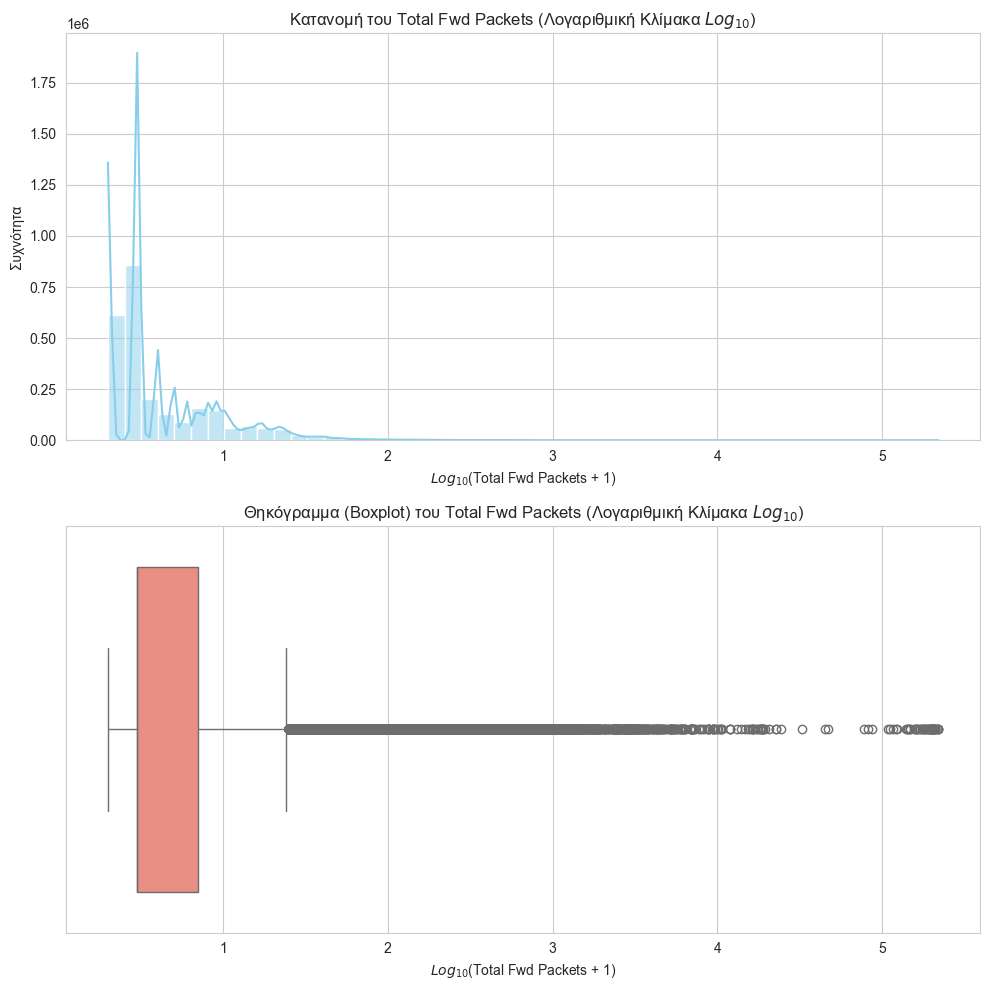

In [9]:
# ΚΕΛΙ 6.2 - Οπτικοποίηση για το Total Fwd Packets
print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Fwd Packets")

# Υπολογισμός λογαρίθμου για σωστή οπτικοποίηση
fwd_packets_log = np.log10(df['Total Fwd Packets'] + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=fwd_packets_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Total Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Total Fwd Packets + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=fwd_packets_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Total Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Total Fwd Packets + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Η κατανομή του αριθμού των forward packets παρουσιάζει έντονη συγκέντρωση σε μικρές τιμές, γεγονός που δείχνει ότι οι περισσότερες δικτυακές ροές αποτελούνται από σχετικά λίγα πακέτα.

Παράλληλα, παρατηρούνται ακραίες τιμές που αντιστοιχούν σε ροές με πολύ μεγάλο αριθμό πακέτων. Τέτοιες περιπτώσεις μπορεί να σχετίζονται με μαζική μεταφορά δεδομένων ή με επιθετική δικτυακή δραστηριότητα.

Η υψηλή διασπορά του χαρακτηριστικού υποδεικνύει σημαντική ετερογένεια στη συμπεριφορά των δικτυακών ροών.
***************************
2) Μορφή και συγκεκριμένα μοτίβα
Μοτίβο Συσσωρευμένων Ακραίων Τιμών (Outliers): Αμέσως μετά τη δεξιά γραμμή (1.4), ξεκινάει μια εξαιρετικά μακριά, παχιά και συμπαγής μαύρη οριζόντια γραμμή που εκτείνεται αδιάκοπα μέχρι το τέρμα δεξιά (5.4). Αυτή η γραμμή σχηματίζεται από χιλιάδες συνεχόμενες τελείες ακραίων τιμών (outliers) που βρίσκονται σε απόλυτη πυκνότητα μεταξύ τους. Κοντεύοντας στο τέλος της γραμμής, οι τελείες αρχίζουν να αραιώνουν ελαφρώς, αλλά παραμένουν ενεργές.
Ερμηνεία: Αυτό το μοτίβο αποκαλύπτει δύο τελείως διαφορετικές συμπεριφορές στο δίκτυο. Η τεράστια συγκέντρωση αριστερά (τιμές κάτω από 1.0, δηλαδή λιγότερα από 10 πακέτα) αντιπροσωπεύει την τυπική, καθημερινή κίνηση όπου οι ανταλλαγές δεδομένων απαιτούν ελάχιστα πακέτα. Αντίθετα, η ατελείωτη μαύρη γραμμή των outliers στα δεξιά αποτυπώνει ροές που μεταφέρουν από εκατοντάδες έως και εκατοντάδες χιλιάδες πακέτα προς τα εμπρός (10^4 με 10^5). Στην κυβερνοασφάλεια, αυτό το μοτίβο αποτελεί την απόλυτη ένδειξη επιθέσεων Flooding και DoS/DDoS, όπου ο επιτιθέμενος «βομβαρδίζει» ασταμάτητα το θύμα με πακέτα για να εξαντλήσει το bandwidth του.
****************************

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Length of Fwd Packets


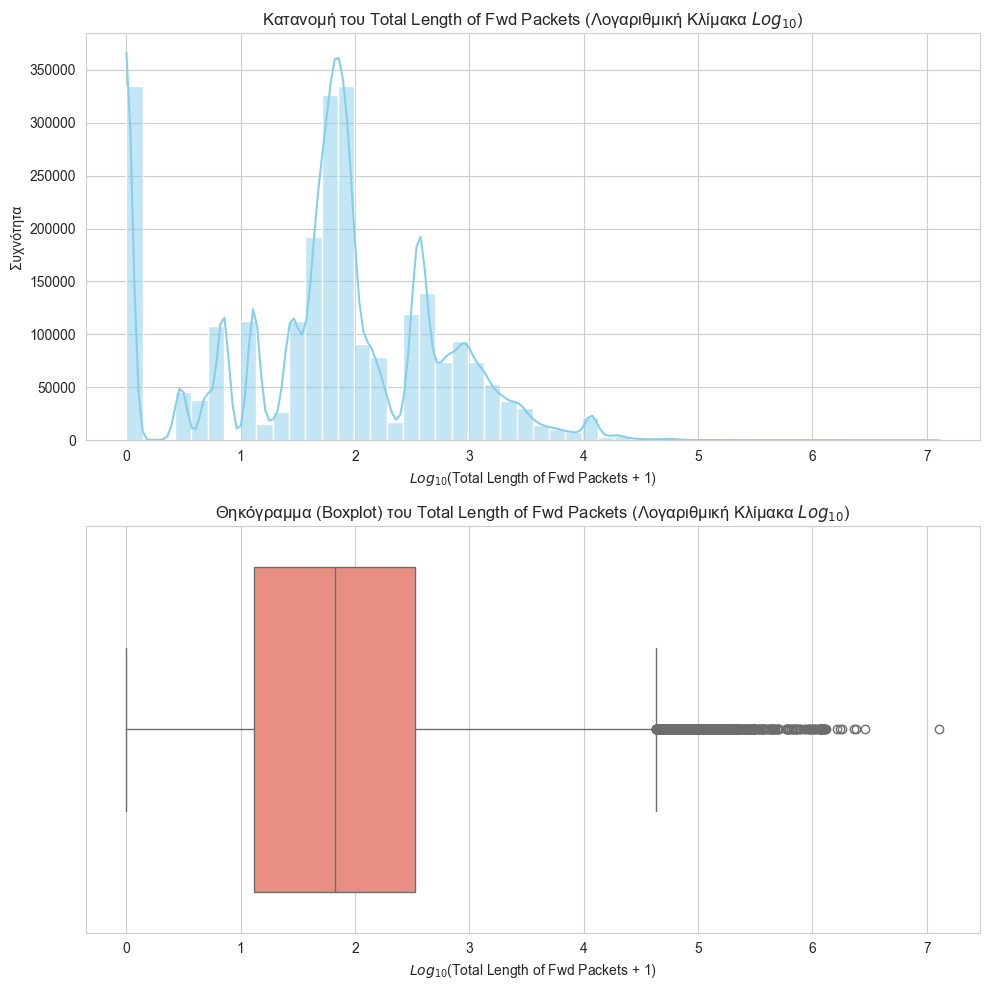

In [10]:
# ΚΕΛΙ 6.3 - Οπτικοποίηση για το Total Length of Fwd Packets
print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Total Length of Fwd Packets")

fwd_length_log = np.log10(df['Total Length of Fwd Packets'] + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=fwd_length_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Total Length of Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Total Length of Fwd Packets + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=fwd_length_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Total Length of Fwd Packets (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Total Length of Fwd Packets + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Το χαρακτηριστικό παρουσιάζει ιδιαίτερα ασύμμετρη κατανομή με μεγάλη συγκέντρωση παρατηρήσεων σε μικρές τιμές και περιορισμένο αριθμό εξαιρετικά μεγάλων τιμών.

Η συμπεριφορά αυτή δείχνει ότι οι περισσότερες δικτυακές ροές μεταφέρουν σχετικά μικρό όγκο δεδομένων, ενώ ορισμένες ροές εμφανίζουν πολύ υψηλό traffic.

Η παρουσία ακραίων τιμών είναι αναμενόμενη σε δεδομένα κυβερνοασφάλειας και μπορεί να σχετίζεται με επιθέσεις υψηλού όγκου ή με μεγάλες μεταφορές αρχείων.
*****************************
2) Μορφή και συγκεκριμένα μοτίβα
Πολυκορυφικό Μοτίβο: Το ιστόγραμμα αποκαλύπτει ένα έντονα πολυκορυφικό μοτίβο με πολλές διακριτές καμπούρες. Αυτό μας δείχνει ότι οι ροές στο δίκτυο χωρίζονται σε πολύ συγκεκριμένες "κατηγορίες" μεγέθους: ροές με μηδενικό/ελάχιστο φορτίο (στο 0), ροές με μικρά πακέτα ελέγχου (γύρω στο 1.0 και 1.8), και ροές μεσαίου μεγέθους δεδομένων (γύρω στο 2.6 με 3.0).
Μοτίβο Ακραίων Τιμών (Outliers) και Ερμηνεία: Μετά τη δεξιά μαύρη γραμμή (4.6), εμφανίζεται μια γραμμή από μεμονωμένες και αραιές κουκκίδες (outliers) που φτάνουν μέχρι το 7.1.
Τα παραπάνω ερμηνεύονται ως εξής: οι καμπούρες αριστερά αντιπροσωπεύουν την τυπική δραστηριότητα (μικρά πακέτα/αιτήματα ιστού). Αντίθετα, οι ακραίες τιμές στα δεξιά (outliers) προδίδουν ροές που κουβαλάνε τεράστιο όγκο δεδομένων. Αυτό το μοτίβο μπορεί να υποδεικνύει είτε επιθέσεις εξαγωγής δεδομένων (Data Exfiltration/κλοπή αρχείων), είτε κακόβουλο "Heavy Flooding" όπου ο επιτιθέμενος στέλνει επίτηδες γιγαντιαία πακέτα για να "μπουκώσει" τις υποδομές του δικτύου.
*********************************

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Packets/s


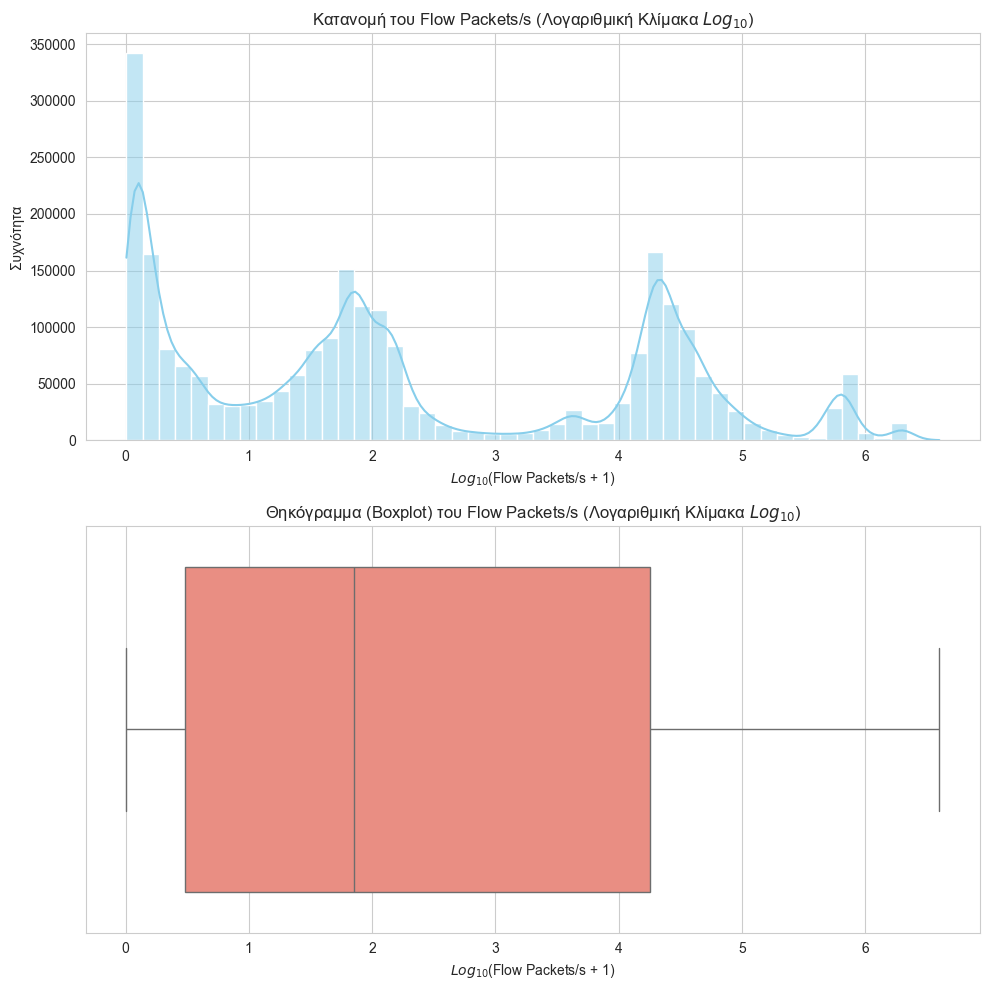

In [11]:
# ΚΕΛΙ 6.4 - Οπτικοποίηση για το Flow Packets/s
print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow Packets/s")

# Αντικατάσταση πιθανών άπειρων τιμών (Inf) που προκύπτουν αν η διάρκεια είναι 0
df['Flow Packets/s'] = df['Flow Packets/s'].replace([np.inf, -np.inf], np.nan)
packets_per_sec_log = np.log10(df['Flow Packets/s'].dropna() + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=packets_per_sec_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Flow Packets/s (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Flow Packets/s + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=packets_per_sec_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Flow Packets/s (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Flow Packets/s + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Το χαρακτηριστικό "Flow Packets/s" εμφανίζει μεγάλη μεταβλητότητα και έντονη δεξιά ασυμμετρία, γεγονός που υποδηλώνει ότι οι περισσότερες ροές έχουν σχετικά χαμηλό ρυθμό πακέτων ανά δευτερόλεπτο.

Ωστόσο, παρατηρούνται και ροές με εξαιρετικά υψηλές τιμές, οι οποίες ενδέχεται να σχετίζονται με αυτοματοποιημένη ή επιθετική δικτυακή δραστηριότητα.

Η ανάλυση του ρυθμού πακέτων αποτελεί σημαντικό στοιχείο για την ανίχνευση ανωμαλιών σε συστήματα IDS.
*******************************
2) Μορφή και συγκεκριμένα μοτίβα
Πολυκορυφικό Μοτίβο: Το ιστόγραμμα αποκαλύπτει ένα κλασικό πολυκορυφικό μοτίβο με τέσσερις πολύ διακριτές καμπούρες (στο 0.1, στο 1.8, στο 4.3 και μια μικρότερη στο 5.8). Αυτό μας δείχνει ότι η ταχύτητα των ροών στο δίκτυο χωρίζεται σε πολύ συγκεκριμένες "ταχύτητες": ροές πολύ χαμηλού ρυθμού (στο 0), ροές μεσαίας ταχύτητας (στο 1.8 και 4.3), και ροές εξαιρετικά υψηλής ταχύτητας (κοντά στο 5.8).
Μοτίβο Ακραίων Τιμών (Outliers) και Ερμηνεία: Στο συγκεκριμένο boxplot παρατηρούμε μια σημαντική ιδιαιτερότητα: δεν εμφανίζονται καθόλου μεμονωμένες κουκκίδες (outliers) μετά τη δεξιά μαύρη γραμμή, καθώς έχει απλωθεί και καλύπτει όλο το εύρος μέχρι το 6.6.
Ερμηνεία: Τα παραπάνω ερμηνεύονται ως εξής: οι καμπούρες αριστερά και στη μέση αντιπροσωπεύουν την τυπική δραστηριότητα και τους φυσιολογικούς ρυθμούς ανταλλαγής πακέτων των χρηστών. Αντίθετα, οι υψηλές τιμές στα δεξιά (γύρω στο 4.3 έως 6.6, που σημαίνει 10^4 έως 10^6 πακέτα το δευτερόλεπτο) προδίδουν ροές με καταιγιστικό ρυθμό αποστολής. Επειδή αυτές οι ακραία υψηλές ταχύτητες δεν εμφανίζονται ως σκόρπιες τελείες αλλά ως συμπαγή, μεγάλα λοφάκια στο ιστόγραμμα, αποτελούν την απόλυτη ένδειξη για οργανωμένες επιθέσεις Flooding ή DoS/DDoS, όπου ο επιτιθέμενος προσπαθεί να "γονατίσει" τον server στέλνοντας εκατομμύρια πακέτα σε χρόνο μηδέν.
***********************************

ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow IAT Mean


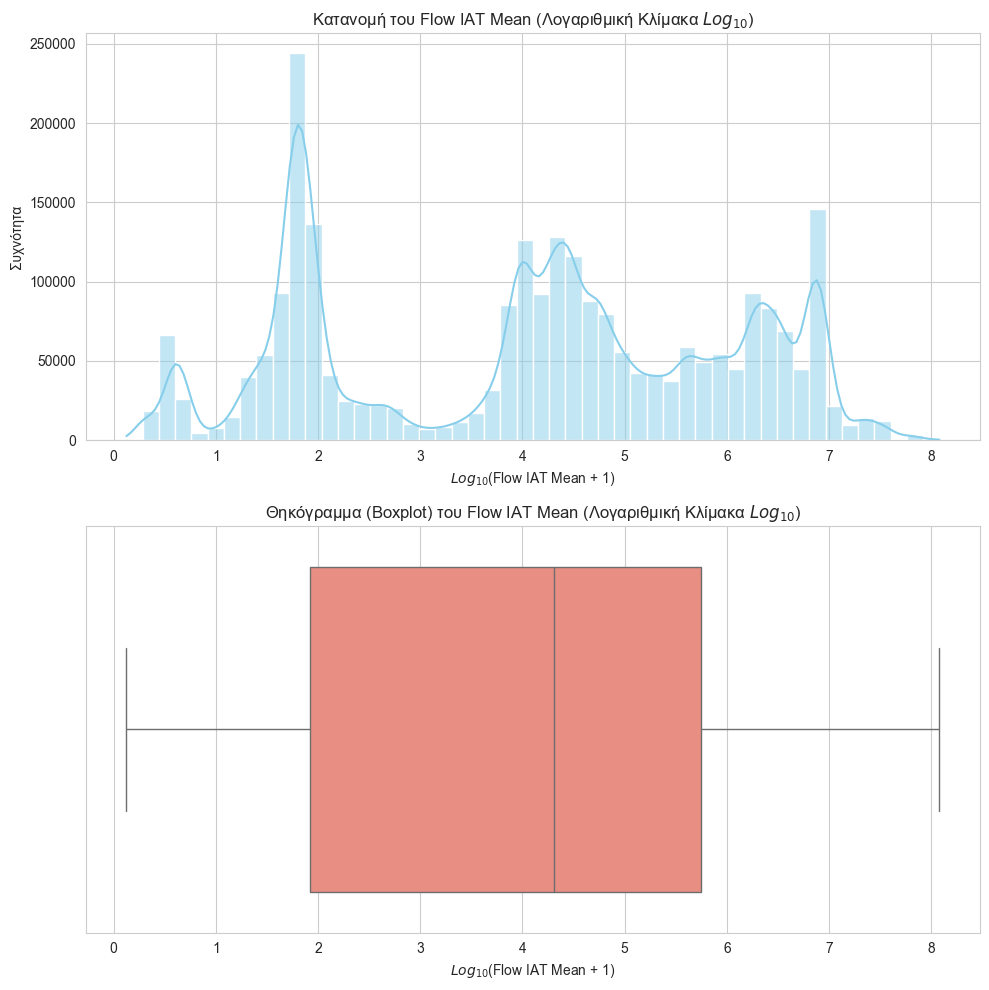

In [12]:
# ΚΕΛΙ 6.5 - Οπτικοποίηση για το Flow IAT Mean
print("ΟΠΤΙΚΟΠΟΙΗΣΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΟΥ: Flow IAT Mean")

iat_mean_log = np.log10(df['Flow IAT Mean'] + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Ιστόγραμμα
sns.histplot(x=iat_mean_log, kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή του Flow IAT Mean (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[0].set_xlabel('$Log_{10}$(Flow IAT Mean + 1)')
axes[0].set_ylabel('Συχνότητα')

# 2. Θηκόγραμμα
sns.boxplot(x=iat_mean_log, ax=axes[1], color='salmon')
axes[1].set_title('Θηκόγραμμα (Boxplot) του Flow IAT Mean (Λογαριθμική Κλίμακα $Log_{10}$)')
axes[1].set_xlabel('$Log_{10}$(Flow IAT Mean + 1)')

plt.tight_layout()
plt.show()

1) Παρατηρήσεις
Το χαρακτηριστικό "Flow IAT Mean" περιγράφει το μέσο χρονικό διάστημα μεταξύ διαδοχικών πακέτων μιας ροής.

Η κατανομή παρουσιάζει σημαντική διασπορά και έντονη ασυμμετρία, γεγονός που υποδηλώνει ότι διαφορετικοί τύποι δικτυακής δραστηριότητας εμφανίζουν διαφορετικά χρονικά πρότυπα επικοινωνίας.

Οι ακραίες τιμές ενδέχεται να σχετίζονται με μη φυσιολογικές καθυστερήσεις ή με αυτοματοποιημένες επιθέσεις που ακολουθούν συγκεκριμένα χρονικά μοτίβα.
*************************************
2) Μορφή και συγκεκριμένα μοτίβα
Πολυκορυφικό Μοτίβο: Το ιστόγραμμα αποκαλύπτει ένα πολύ καθαρό πολυκορυφικό μοτίβο με τέσσερις κύριες καμπούρες (στο 1.8, στο 4.3, στο 6.3 και στο 6.9), καθώς και μια μικρότερη στην αρχή (γύρω στο 0.6). Αυτό μας δείχνει ότι οι καθυστερήσεις μεταξύ των πακέτων διαχωρίζονται σε πολύ συγκεκριμένες χρονικές κλάσεις: από εξαιρετικά μικρές (μικρότερες από millisecond), σε μεσαίες, έως και πολύ μεγάλες (δευτερόλεπτα ή λεπτά).
Μοτίβο Ακραίων Τιμών (Outliers) και Ερμηνεία: Όπως και στο προηγούμενο χαρακτηριστικό, στο boxplot δεν εμφανίζονται καθόλου μεμονωμένες κουκκίδες (outliers), καθώς η δεξιά μαύρη γραμμή απλώνεται και ενσωματώνει όλο το εύρος των μεγάλων τιμών μέχρι το 8.1.
Ερμηνεία: Τα παραπάνω ερμηνεύονται ως εξής: η πρώτη μεγάλη καμπούρα αριστερά (γύρω στο 1.8, δηλαδή μερικά milliseconds) προδίδει ροές με πολύ γρήγορη και συνεχή αποστολή πακέτων. Ένας πολύ μικρός μέσος χρόνος μεταξύ των πακέτων αποτελεί κλασικό αποτύπωμα επιθέσεων DoS/DDoS Flooding, όπου τα πακέτα στέλνονται ακατάπαυστα το ένα πίσω από το άλλο για να εξαντλήσουν τους πόρους. Αντίθετα, οι καμπούρες στα δεξιά (από 4.3 έως 7.0, που σημαίνει από αρκετά δευτερόλεπτα έως και λεπτά καθυστέρησης) αντιπροσωπεύουν είτε την τυπική, σκόρπια δραστηριότητα των απλών χρηστών (π.χ. ανάγνωση μιας σελίδας), είτε επιθέσεις τύπου "Slowloris" / Slow DoS, οι οποίες στέλνουν πακέτα πολύ αργά και μεθοδικά για να κρατούν τις γραμμές του server απασχολημένες χωρίς να γίνονται εύκολα αντιληπτές από τα συστήματα ασφαλείας.
****************************************


LABEL DISTRIBUTION TABLE:

                     Label  Total Count  Percentage (%)
                    BENIGN      2095057         83.1109
                  DoS Hulk       172846          6.8568
                      DDoS       128014          5.0783
                  PortScan        90694          3.5978
             DoS GoldenEye        10286          0.4080
               FTP-Patator         5931          0.2353
             DoS slowloris         5385          0.2136
          DoS Slowhttptest         5228          0.2074
               SSH-Patator         3219          0.1277
                       Bot         1948          0.0773
  Web Attack - Brute Force         1470          0.0583
          Web Attack - XSS          652          0.0259
              Infiltration           36          0.0014
Web Attack - Sql Injection           21          0.0008
                Heartbleed           11          0.0004


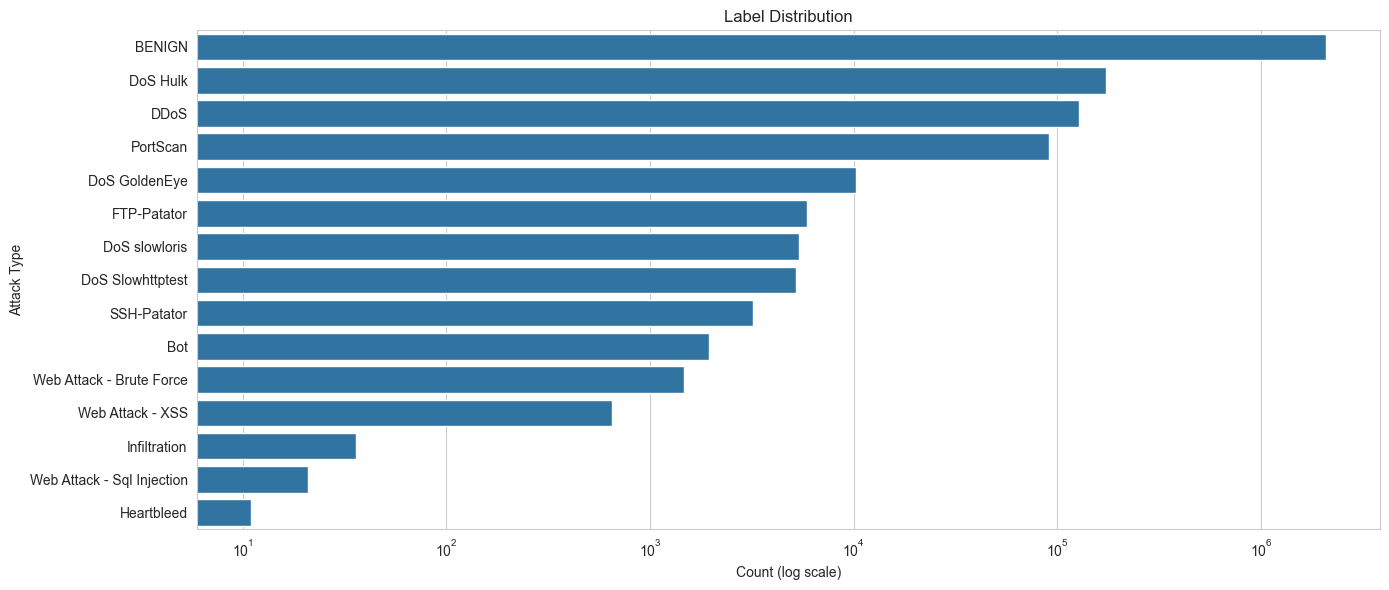

In [13]:
# ΚΕΛΙ 7

# Αντικατάσταση προβληματικών χαρακτήρων ("?" και "□") με "-"
df['Label'] = (
    df['Label']
    .astype(str)
    .str.replace('?', '-', regex=False)
    .str.replace('�', '-', regex=False)
    .str.replace('□', '-', regex=False)
)

# Υπολογισμός counts και percentages
label_counts = df['Label'].value_counts()
label_percentages = df['Label'].value_counts(normalize=True) * 100

# Δημιουργία πίνακα
label_table = pd.DataFrame({
    'Label': label_counts.index,
    'Total Count': label_counts.values,
    'Percentage (%)': label_percentages.values
})

# Μορφοποίηση ποσοστών
label_table['Percentage (%)'] = label_table['Percentage (%)'].round(4)

# Εμφάνιση ΟΛΟΚΛΗΡΟΥ πίνακα χωρίς "..."
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Εμφάνιση πίνακα
print("\nLABEL DISTRIBUTION TABLE:\n")
print(label_table.to_string(index=False))

plt.figure(figsize=(14,6))

sns.countplot(
    y=df['Label'],
    order=df['Label'].value_counts().index
)

plt.xscale('log')

plt.title("Label Distribution")
plt.xlabel("Count (log scale)")
plt.ylabel("Attack Type")

plt.tight_layout()
plt.show()



Class Imbalance: Η κατανομή της μεταβλητής στόχου παρουσιάζει σημαντική ανισορροπία μεταξύ των κλάσεων. Η κατηγορία BENIGN εμφανίζεται με πολύ μεγαλύτερη συχνότητα (83,11%) σε σχέση με αρκετές κατηγορίες επιθέσεων.

Η ανισορροπία κλάσεων αποτελεί σημαντικό πρόβλημα, καθώς τα μοντέλα μηχανικής μάθησης μπορεί να τείνουν να προβλέπουν συχνότερα την κυρίαρχη κλάση, οδηγώντας σε παραπλανητικά υψηλή ακρίβεια (τα μοντέλα αρχίζουν να μεροληπτούν).

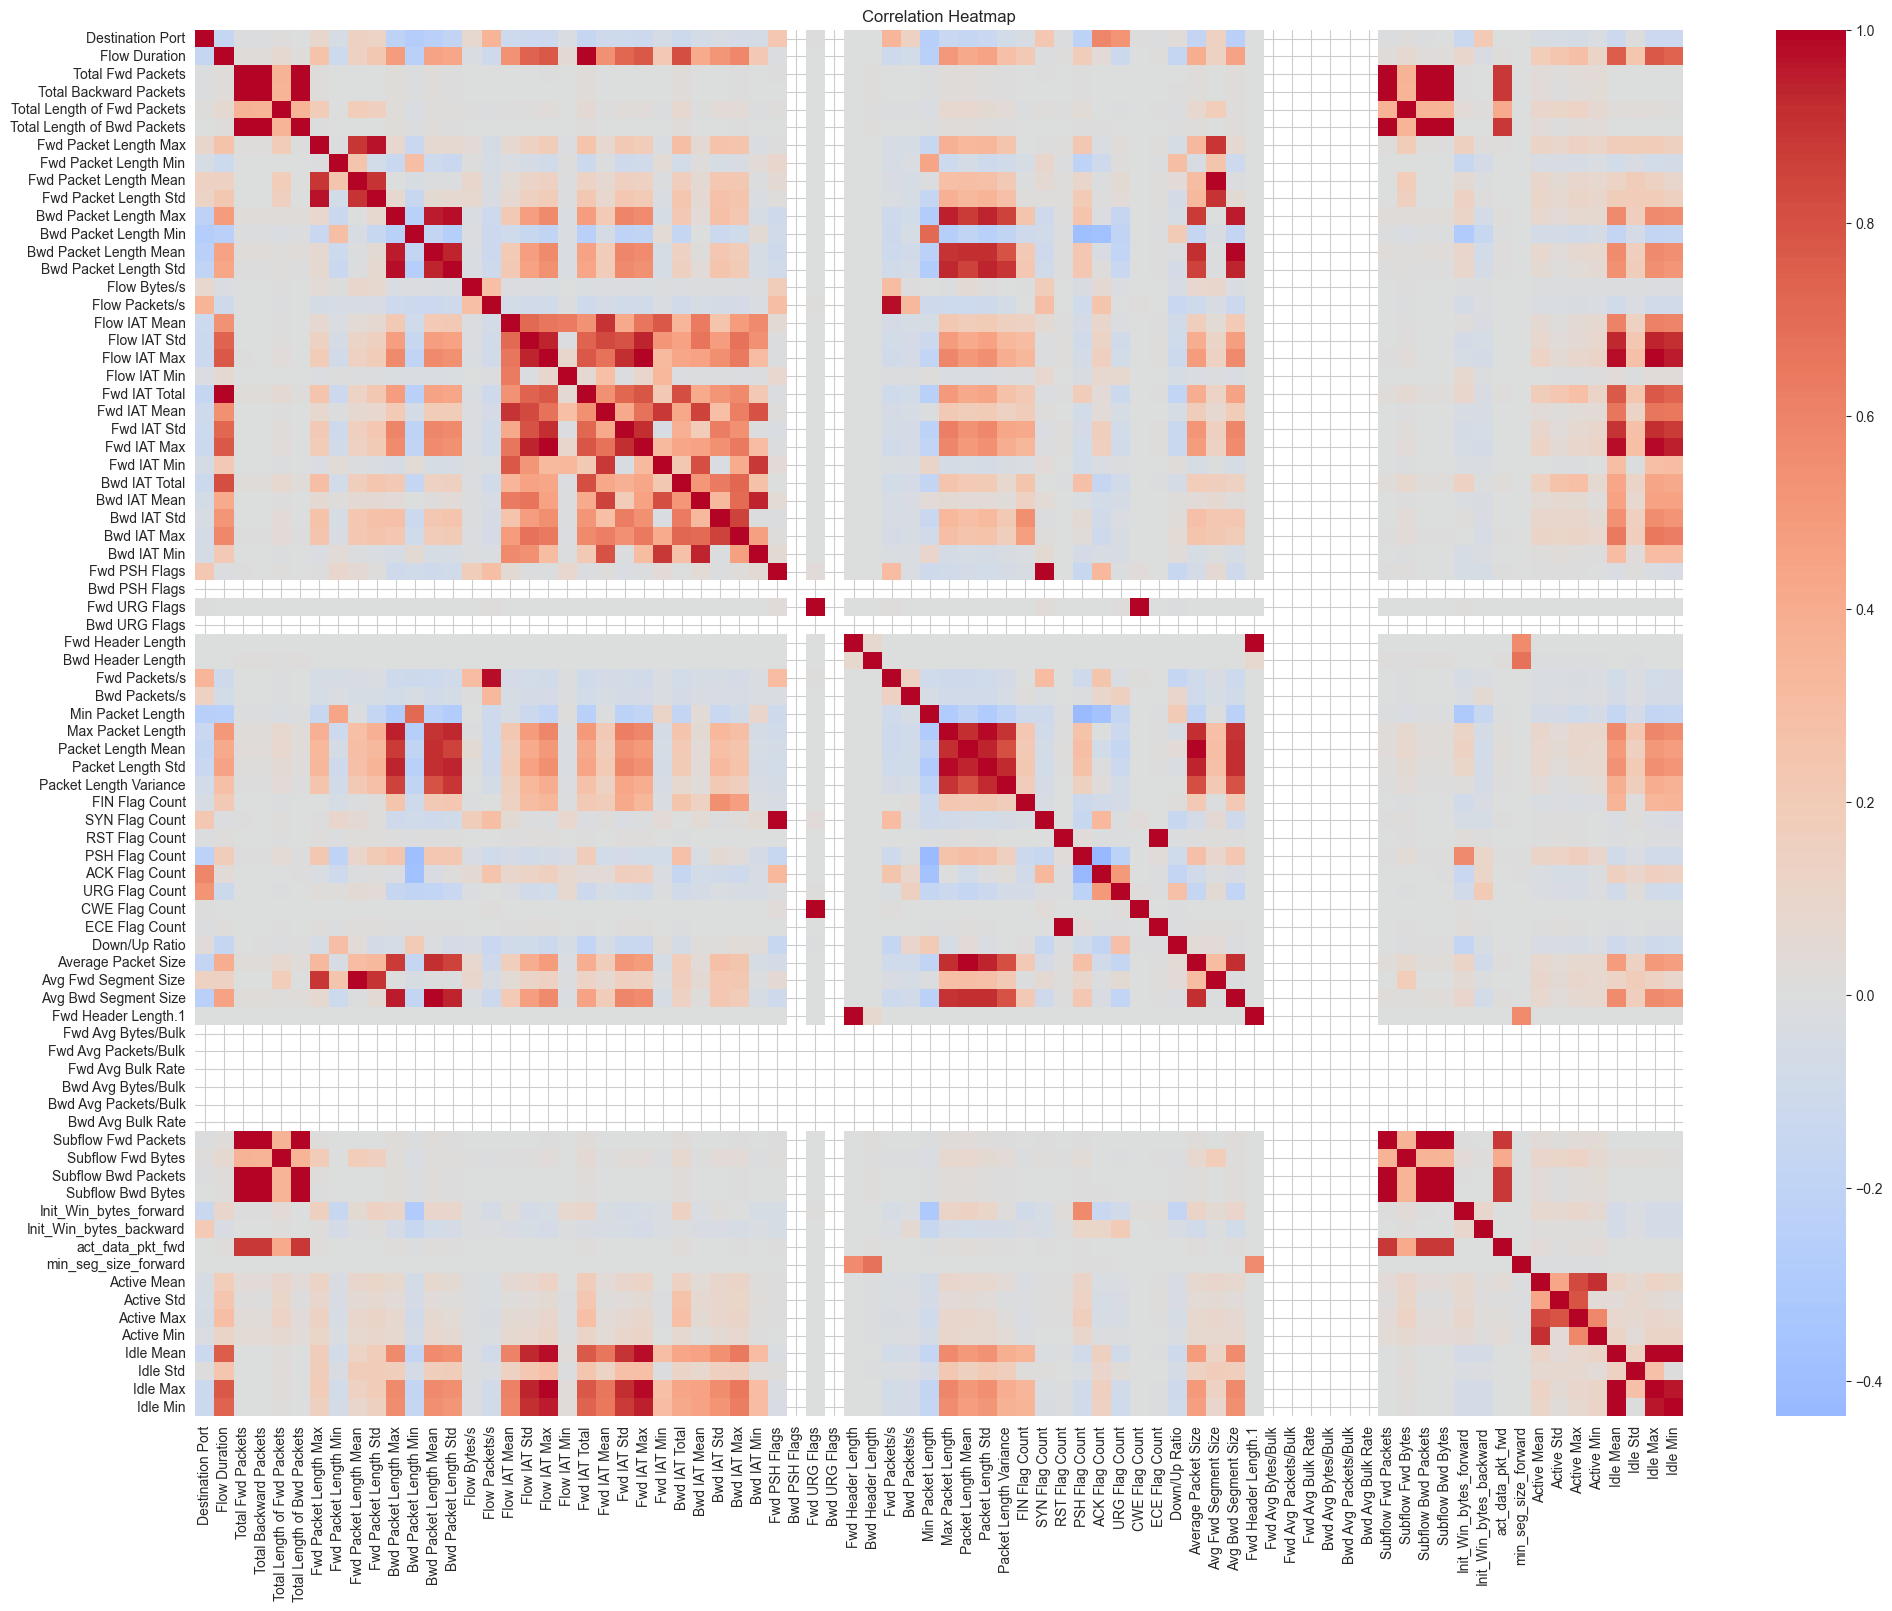

In [14]:
# ΚΕΛΙ 8

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24,18))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

***********************
Το γράφημα βασίζεται στον Συντελεστή Συσχέτισης του Pearson (r). Κάθε τετράγωνο στο πλέγμα αντιπροσωπεύει τη σχέση μεταξύ της μεταβλητής της γραμμής και της μεταβλητής της στήλης. Οι τιμές αυτού του συντελεστή κυμαίνονται αυστηρά από -1 έως +1 και το χρώμα μας δείχνει το αποτέλεσμα:
Τέλεια Θετική Συσχέτιση (r περίπου 1 /Έντονο Κόκκινο): Σημαίνει ότι οι δύο μεταβλητές είναι ανάλογες, όταν η μία αυξάνεται, η άλλη αυξάνεται σχεδόν αυτόματα και αναλογικά.
Καμία Συσχέτιση (r περίπου 0 /Ανοιχτό Γκρι-Λευκό): Σημαίνει ότι οι δύο μεταβλητές είναι εντελώς ανεξάρτητες. Το τι κάνει η μία δεν επηρεάζει καθόλου την άλλη.
Αρνητική Συσχέτιση (r περίπου -0.2 /Ανοιχτό Μπλε): Σημαίνει ότι οι μεταβλητές κινούνται αντίθετα. Όταν η μία ανεβαίνει, η άλλη πέφτει.

Η Κόκκινη Διαγώνιος: Είναι η γραμμή που ξεκινάει από πάνω αριστερά και καταλήγει κάτω δεξιά. Έχει παντού την τιμή 1 (κόκκινη), επειδή προκύπτει από τη συσχέτιση κάθε μεταβλητής με τον ίδιο της τον εαυτό (π.χ. το Flow Duration με το Flow Duration).

Τα Συμπαγή Κόκκινα Τετράγωνα (Clusters): Τα κόκκινα κουτάκια δεν είναι διάσπαρτα, αλλά σχηματίζουν ολόκληρα τετράγωνα «μπλοκ». Αυτό στατιστικά σημαίνει ότι ολόκληρες ομάδες μεταβλητών κινούνται με τον ίδιο ακριβώς ρυθμό και μεταφέρουν, ουσιαστικά, την ίδια πληροφορία.

Οι Γκρίζες Λωρίδες (Dead Zones): Υπάρχουν κάποιες οριζόντιες και κάθετες γραμμές (όπως στο Fwd URG Flags ή στα Bulk πεδία) που είναι εντελώς γκρίζες ή λευκές. Αυτό σημαίνει ότι οι συγκεκριμένες στήλες στο dataset έχουν παντού την ίδια τιμή (π.χ. είναι όλες 0). Επειδή δεν αλλάζουν ποτέ (δεν έχουν variance), τα μαθηματικά δεν μπορούν να βρουν καμία συσχέτιση με τίποτα άλλο.
***********************

In [15]:
# ΚΕΛΙ 9
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(abs(upper[column]) > 0.95)
]

print("Highly Correlated Features:")
print(high_corr_features)

Highly Correlated Features:
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']


Στο στάδιο αυτό εντοπίστηκαν χαρακτηριστικά με πολύ υψηλή συσχέτιση, τα οποία πιθανόν περιέχουν πλεονάζουσα πληροφορία.

Η διατήρηση μεγάλου αριθμού ισχυρά συσχετισμένων χαρακτηριστικών μπορεί:
- να αυξήσει την πολυπλοκότητα του μοντέλου,
- να επηρεάσει την ερμηνευσιμότητα,
- και να οδηγήσει σε φαινόμενα πολυσυγγραμμικότητας.

Για τον λόγο αυτό, τα χαρακτηριστικά με απόλυτη τιμή συσχέτισης μεγαλύτερη από 0.95 επιλέχθηκαν ως υποψήφια προς αφαίρεση.
Σε αυτό συνέβαλε η εντολή abs που βρίσκει και strong negative correlations εκτός από strong positive correlations.

In [16]:
#ΚΕΛΙ 10
# Η μέθοδος εφαρμόζεται στα αρχικά δεδομένα και μπορεί
# να επηρεάζεται από την κλίμακα των χαρακτηριστικών.
selector = VarianceThreshold(threshold=0.01)

selector.fit(numeric_df)

low_variance_features = numeric_df.columns[
    ~selector.get_support()
]

print("Low Variance Features:")
print(list(low_variance_features))

Low Variance Features:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


Αφαίρεση Χαρακτηριστικών Χαμηλής Διακύμανσης

Η μέθοδος Variance Threshold χρησιμοποιήθηκε για τον εντοπισμό χαρακτηριστικών με πολύ μικρή μεταβλητότητα.

Χαρακτηριστικά με σχεδόν σταθερές τιμές παρέχουν περιορισμένη πληροφορία στα μοντέλα μηχανικής μάθησης και συχνά δεν συμβάλλουν ουσιαστικά στη διαδικασία ταξινόμησης.

Η αφαίρεση τέτοιων χαρακτηριστικών συμβάλλει:
- στη μείωση της διαστασιμότητας,
- στη βελτίωση της αποδοτικότητας,
- και στη μείωση του θορύβου του dataset.

In [17]:
# ΚΕΛΙ 11
features_to_drop = list(high_corr_features) + list(low_variance_features)

features_to_drop = list(set(features_to_drop))

print("Features to remove:")
print(features_to_drop)

feature_removal_summary = pd.DataFrame({
    'Feature': features_to_drop,
    'Reason': [
        'High Correlation' if f in high_corr_features else 'Low Variance'
        for f in features_to_drop
    ]
})

feature_removal_summary
df_reduced = df.drop(columns=features_to_drop)

print("\nOriginal Shape:", df.shape)
print("Reduced Shape:", df_reduced.shape)

Features to remove:
['Avg Fwd Segment Size', 'Fwd Avg Bulk Rate', 'ECE Flag Count', 'Bwd Packet Length Std', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Subflow Fwd Bytes', 'Bwd Packet Length Mean', 'Average Packet Size', 'Subflow Bwd Bytes', 'Idle Max', 'Fwd Avg Bytes/Bulk', 'Bwd URG Flags', 'Packet Length Std', 'SYN Flag Count', 'Fwd Avg Packets/Bulk', 'RST Flag Count', 'Fwd URG Flags', 'Bwd Avg Packets/Bulk', 'Fwd Packets/s', 'Subflow Fwd Packets', 'Fwd Header Length.1', 'Idle Mean', 'Avg Bwd Segment Size', 'Idle Min', 'Bwd Avg Bytes/Bulk', 'Subflow Bwd Packets', 'Bwd Avg Bulk Rate', 'CWE Flag Count', 'Total Backward Packets', 'Bwd PSH Flags', 'Fwd IAT Total', 'Fwd IAT Max']

Original Shape: (2520798, 79)
Reduced Shape: (2520798, 46)


Τελική Επιλογή Χαρακτηριστικών

Στο τελικό στάδιο της προεπεξεργασίας πραγματοποιήθηκε συνδυαστική αφαίρεση χαρακτηριστικών με:
- πολύ υψηλή συσχέτιση,
- ή πολύ χαμηλή διακύμανση.

Η διαδικασία αυτή αποσκοπεί στη μείωση της πλεονάζουσας πληροφορίας και στη βελτίωση της ποιότητας του dataset.

Η απομάκρυνση έντονα συσχετισμένων χαρακτηριστικών συμβάλλει στη μείωση της πολυσυγγραμμικότητας, ενώ η αφαίρεση χαρακτηριστικών χαμηλής διακύμανσης περιορίζει την παρουσία χαρακτηριστικών με μικρή πληροφοριακή αξία.

Το τελικό σύνολο χαρακτηριστικών θεωρείται περισσότερο κατάλληλο για τα επόμενα στάδια ανάλυσης και εκπαίδευσης μοντέλων μηχανικής μάθησης.

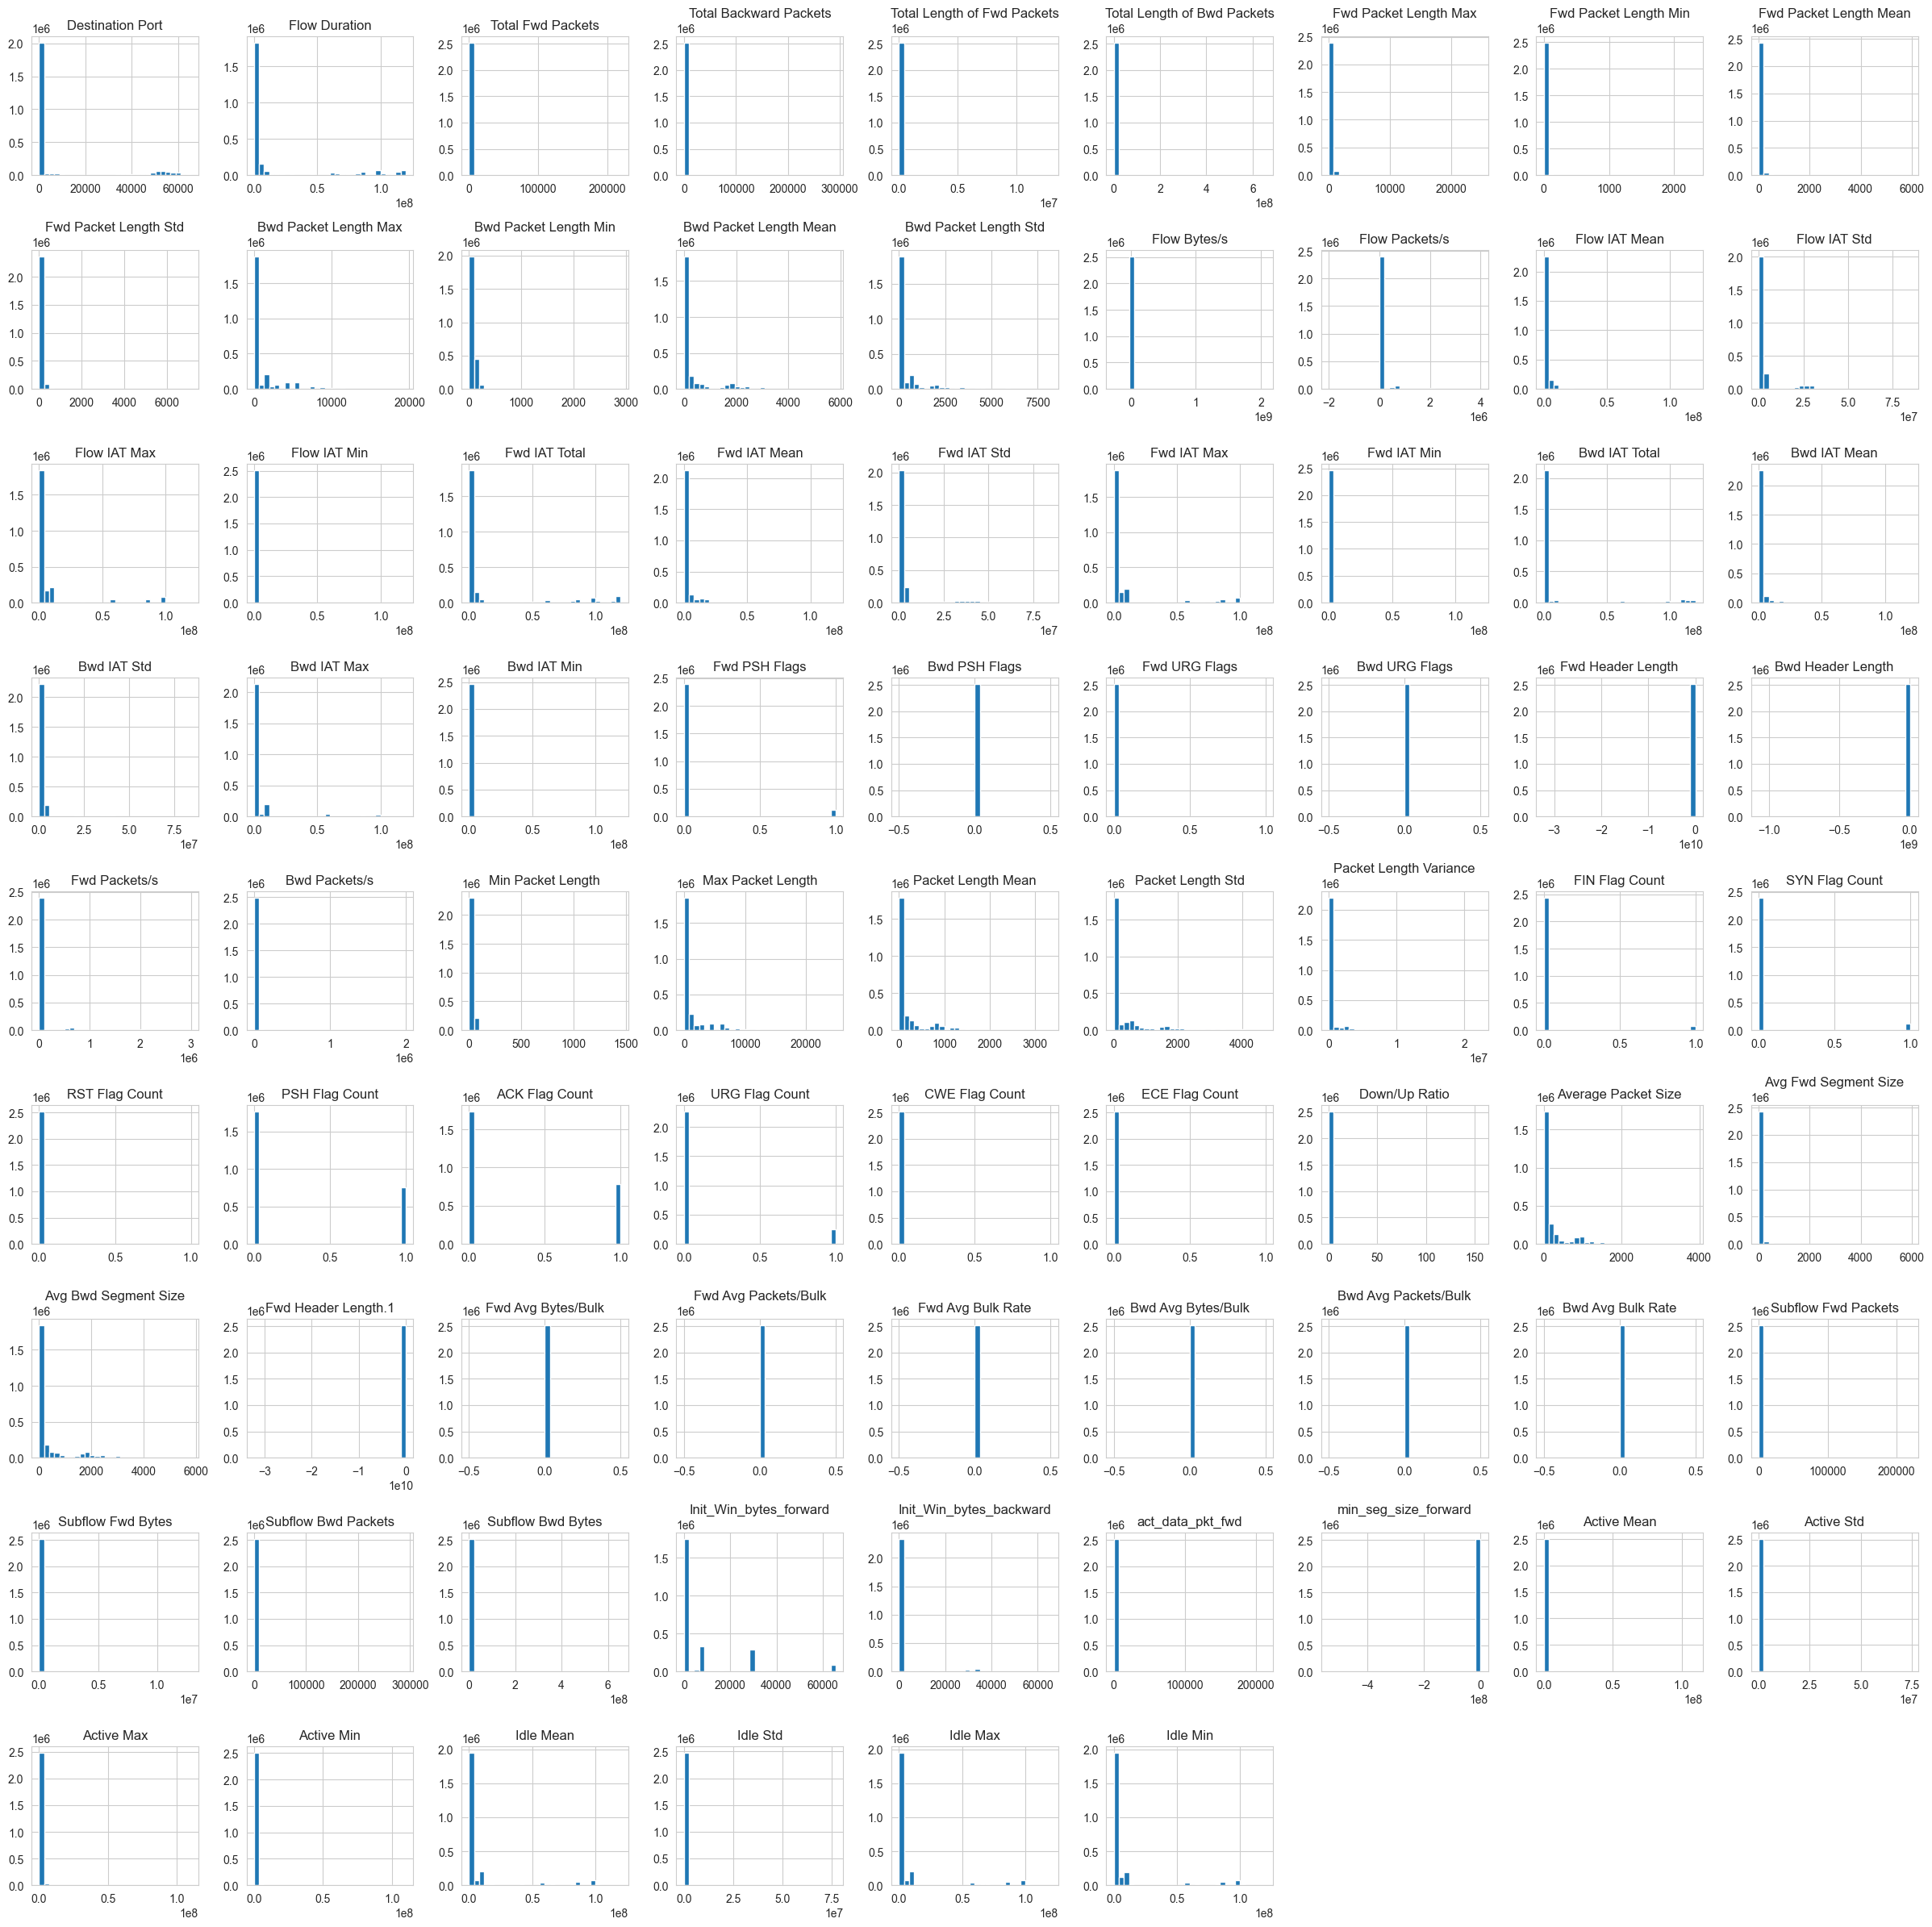

In [18]:
# ΚΕΛΙ 12
numeric_df.hist(figsize=(24,24), bins=30)

plt.tight_layout()
plt.show()

Κατανομές όλων των Αριθμητικών Χαρακτηριστικών

Για την συνολική διερεύνηση των κατανομών εφαρμόστηκαν ιστογράμματα σε όλες τις αριθμητικές μεταβλητές του dataset.

Από την ανάλυση παρατηρείται ότι η πλειοψηφία των χαρακτηριστικών παρουσιάζει έντονη δεξιά ασυμμετρία (right-skewed distributions), με συγκέντρωση τιμών σε χαμηλές περιοχές και εκτεταμένες ουρές προς μεγαλύτερες τιμές.

Το μοτίβο αυτό είναι χαρακτηριστικό σε δεδομένα δικτυακής κίνησης, όπου η πλειοψηφία των ροών είναι μικρής διάρκειας και χαμηλού όγκου, ενώ ένα μικρό ποσοστό ροών αντιστοιχεί σε ασυνήθιστη ή κακόβουλη δραστηριότητα.

In [19]:
# ΚΕΛΙ 13
# Διαχωρισμός σε Χαρακτηριστικά (X) και Μεταβλητή Στόχο (y)
X = df_reduced.drop(columns=['Label'])
y = df_reduced['Label']

# Εκτύπωση των σχημάτων (Shapes)
print("Features Shape (X):", X.shape)
print("Target Shape (y):", y.shape)

Features Shape (X): (2520798, 45)
Target Shape (y): (2520798,)


Διαχωρισμός Χαρακτηριστικών και Μεταβλητής Στόχου
Στο στάδιο αυτό, ξεκινά η προετοιμασία των δεδομένων για την εκπαίδευση των μοντέλων επιβλεπόμενης μάθησης. 
Διαχωρίζουμε το μειωμένο σύνολο δεδομένων (`df_reduced`) που προέκυψε από το Ερώτημα 1 στις εξής μεταβλητές:
- X (Features): Πίνακας που περιέχει όλες τα χαρακτηριστικά της δικτυακής κίνησης.
- y (Target): Μονοδιάστατο διάνυσμα που περιέχει τη μεταβλητή στόχο (`Label`), δηλαδή την κατηγορία του  τύπου επίθεσης.

In [20]:
# ΚΕΛΙ 14
# Αρχικοποίηση και εφαρμογή του LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Εκτύπωση των κλάσεων με τη δομή: Όνομα Κλάσης --> Αριθμός
print("Αντιστοίχιση Κλάσεων (Label Mapping):")
for index, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {index}")

Αντιστοίχιση Κλάσεων (Label Mapping):
BENIGN --> 0
Bot --> 1
DDoS --> 2
DoS GoldenEye --> 3
DoS Hulk --> 4
DoS Slowhttptest --> 5
DoS slowloris --> 6
FTP-Patator --> 7
Heartbleed --> 8
Infiltration --> 9
PortScan --> 10
SSH-Patator --> 11
Web Attack - Brute Force --> 12
Web Attack - Sql Injection --> 13
Web Attack - XSS --> 14


Κωδικοποίηση Μεταβλητής Στόχου (Label Encoding)
Επειδή οι αλγόριθμοι της `scikit-learn` βασίζονται σε μαθηματικές εξισώσεις και απαιτούν αποκλειστικά αριθμητικές τιμές εισόδου για την εκπαίδευσή τους, χρησιμοποιούμε τον `LabelEncoder`. 
Με τη μέθοδο αυτή, μετατρέπουμε τα δεδομένα σε μορφή κειμένου (strings) της στήλης `Label` σε ακέραιους αριθμούς (0, 1, 2...). Παράλληλα, τυπώνουμε την αντιστοίχιση των κλάσεων, η οποία θα μας επιτρέψει στο τέλος της διαδικασίας να ερμηνεύσουμε σωστά τις προβλέψεις των μοντέλων.

In [21]:
# ΚΕΛΙ 15
# Πρώτο Split: Απομονώνουμε το 20% για το τελικό Test Set
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Δεύτερο Split (Μόνο για το Σενάριο Α): Σπάμε το 80% σε Train (60% του αρχικού) και Validation (20% του αρχικού)
# Το 0.25 του 80% ισούται ακριβώς με το 20% του αρχικού συνόλου
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


Διαχωρισμός Δεδομένων (Train / Validation / Test Split)
Χωρίζουμε τα δεδομένα σε δύο στάδια χρησιμοποιώντας την τεχνική (`stratify`), ώστε να διατηρηθεί η αναλογία των κλάσεων (αντιμετώπιση του class imbalance):
1. Απομόνωση Test Set (20%): Κρατείται ως εντελώς κρυφό σύνολο για την τελική, δίκαιη σύγκριση και των δύο σεναρίων.
2. Διαχωρισμός Train (60%) / Validation (20%): Προκύπτει από το υπόλοιπο 80% (`X_temp`) και θα χρησιμοποιηθεί αποκλειστικά για το χειροκίνητο Grid Search του Σεναρίου Α. 
Στο Σενάριο Β (Cross-Validation), ολόκληρο το ενιαίο 80% (`X_temp`) θα δοθεί στο `GridSearchCV`.

In [22]:
# ΚΕΛΙ 16
# Αρχικοποίηση του StandardScaler
scaler = StandardScaler()

# 1. Εκπαίδευση του scaler ΜΟΝΟ στο X_train και μετασχηματισμός του (Σενάριο Α)
X_train_scaled = scaler.fit_transform(X_train)

# 2. Μετασχηματισμός των υπόλοιπων συνόλων χρησιμοποιώντας ΜΟΝΟ τη μέθοδο .transform()
X_val_scaled = scaler.transform(X_val)      # Για το Σενάριο Α
X_test_scaled = scaler.transform(X_test)    # Για την τελική αξιολόγηση και των δύο σεναρίων
X_temp_scaled = scaler.transform(X_temp)    # Για το Σενάριο Β (Cross-Validation)

print(f"Διαστάσεις X_train_scaled: {X_train_scaled.shape}")
print(f"Διαστάσεις X_val_scaled:   {X_val_scaled.shape}")
print(f"Διαστάσεις X_temp_scaled:  {X_temp_scaled.shape}")
print(f"Διαστάσεις X_test_scaled:  {X_test_scaled.shape}")

Διαστάσεις X_train_scaled: (1512478, 45)
Διαστάσεις X_val_scaled:   (504160, 45)
Διαστάσεις X_temp_scaled:  (2016638, 45)
Διαστάσεις X_test_scaled:  (504160, 45)


Τυποποίηση Χαρακτηριστικών (Feature Scaling)
Η τυποποίηση των δεδομένων ολοκληρώθηκε επιτυχώς με τη χρήση του `StandardScaler`. Τα χαρακτηριστικά μετασχηματίστηκαν ώστε να έχουν μέση τιμή 0 και τυπική απόκλιση 1, εξασφαλίζοντας ότι αλγόριθμοι ευαίσθητοι στην κλίμακα (όπως η Logistic Regression) θα λειτουργήσουν σωστά χωρίς να επηρεάζονται από τις μεγάλες αριθμητικές διαφορές μεταξύ των στηλών.

**Διασφάλιση Στατιστικής Εγκυρότητας (Αποφυγή Data Leakage):**
Για την αποφυγή διαρροής πληροφοριών, ο scaler εκπαιδεύτηκε `.fit()` αποκλειστικά στο σύνολο `X_train`. Τα υπόλοιπα σύνολα δεδομένων (`X_val`, `X_test`, και το ενιαίο `X_temp`) μετασχηματίστηκαν χρησιμοποιώντας μόνο τη μέθοδο `.transform()`.

Όπως φαίνεται από τα αποτελέσματα, οι διαστάσεις των πινάκων επαληθεύουν την ακριβή μοιρασιά των γραμμών σε αναλογία 60% / 20% / 20%.

In [24]:
# ΚΕΛΙ 17

import warnings

warnings.filterwarnings('ignore')

# Ορισμός των υπερπαραμέτρων προς δοκιμή (Αντίστροφη ισχύς τακτοποίησης)
c_values = [0.1, 1.0, 10.0]

best_macro_f1 = 0
best_c = None
results_list = []

print("Έναρξη Χειροκίνητου Grid Search για την Logistic Regression (Σενάριο Α)...")
print("-" * 75)

for c in c_values:
    print(f"Εκπαίδευση μοντέλου με C = {c}...")
    
    # Αρχικοποίηση μοντέλου με n_jobs=-1 για ταχύτητα και max_iter για σίγουρη σύγκλιση
    lr_model = LogisticRegression(C=c, max_iter=150, solver='lbfgs', n_jobs=-1, random_state=42)
    
    # Εκπαίδευση στο Train Set
    lr_model.fit(X_train_scaled, y_train)
    
    # Πρόβλεψη στο Validation Set
    y_val_pred = lr_model.predict(X_val_scaled)
    
    # Υπολογισμός Macro F1-Score (κατάλληλο για ανισόρροπα δεδομένα)
    macro_f1 = f1_score(y_val, y_val_pred, average='macro')
    results_list.append((c, macro_f1))
    
    print(f"-> Validation Macro F1-Score για C={c}: {macro_f1:.4f}")
    
    # Έλεγχος αν είναι το καλύτερο σκορ
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_c = c

print("-" * 75)
print("Το Χειροκίνητο Grid Search ολοκληρώθηκε!")
print(f"Καλύτερη υπερπαράμετρος: C = {best_c} με Macro F1-Score = {best_macro_f1:.4f}")

Έναρξη Χειροκίνητου Grid Search για την Logistic Regression (Σενάριο Α)...
---------------------------------------------------------------------------
Εκπαίδευση μοντέλου με C = 0.1...
-> Validation Macro F1-Score για C=0.1: 0.4631
Εκπαίδευση μοντέλου με C = 1.0...
-> Validation Macro F1-Score για C=1.0: 0.5578
Εκπαίδευση μοντέλου με C = 10.0...
-> Validation Macro F1-Score για C=10.0: 0.5600
---------------------------------------------------------------------------
Το Χειροκίνητο Grid Search ολοκληρώθηκε!
Καλύτερη υπερπαράμετρος: C = 10.0 με Macro F1-Score = 0.5600


# Επιλογή Υπερπαραμέτρων μέσω Χειροκίνητου Grid Search (Σενάριο Α)

* Χειροκίνητη Υλοποίηση (for loop): Η εκφώνηση για το Σενάριο Α απαιτεί τη χρήση σταθερού διαχωρισμού (Train/Validation split). Επειδή το έτοιμο εργαλείο `GridSearchCV` της scikit-learn εκτελεί αυτόματα Cross-Validation (K-Folds), η χρήση του θα παραβίαζε τους περιορισμούς του Σεναρίου Α. Επομένως, κατασκευάστηκε ένας χειροκίνητος βρόχος για την αξιολόγηση των μοντέλων.
* Χρήση του Validation Set: Η εκπαίδευση έγινε στο `X_train_scaled`, αλλά η επιλογή της καλύτερης τιμής για την υπερπαράμετρο C βασίστηκε αποκλειστικά στις επιδόσεις στο `X_val_scaled`. Αυτό είναι απαράτητο ώστε το τελικό Test Set να παραμείνει εντελώς ανέπαφο για την τελική αξιολόγηση.
* Επιλογή Μετρικής (Macro F1-Score): Λόγω της έντονης ανισορροπίας των κλάσεων στο dataset, το Macro F1-Score επιλέχθηκε ως η μοναδική αντικειμενική μετρική ("πυξίδα"), καθώς δίνει την ίδια βαρύτητα σε όλες τις κλάσεις (δημοφιλείς και σπάνιες), εμποδίζοντας το μοντέλο να παραπλανήσει με ένα πλασματικά υψηλό Accuracy.

# Παρατήρηση
Κατά τις δοκιμές της υπερπαραμέτρου C, παρατηρήθηκαν τα εξής αποτελέσματα στο Validation Set:
* C = 0.1  --> Macro F1-Score: 0.4631
* C = 1.0  --> Macro F1-Score: 0.5578
* C = 10.0 --> Macro F1-Score: 0.5600

# Συμπέρασμα
 Καθώς η τιμή του C αυξάνεται, η ποινή τακτοποίησης (regularization) εξασθενεί. Αυτό επιτρέπει στον αλγόριθμο να γίνει πιο "ελαστικός" και να προσαρμοστεί καλύτερα στα δεδομένα εκπαίδευσης. Η σταδιακή άνοδος του Macro F1 δείχνει ότι η μείωση της ποινής βοηθάει το μοντέλο να αναγνωρίσει καλύτερα κάποιες από τις μειονοτικές κλάσεις (επιθέσεις) που σε αυστηρότερες συνθήκες (C=0.1) τις αγνοούσε τελείως.
Ως συμπέρασμα, η τιμή C = 10.0 επιλέχθηκε ως η βέλτιστη υπερπαράμετρος για την Logistic Regression στο Σενάριο Α, και με αυτήν θα προχωρήσουμε στην τελική αξιολόγηση. 
Η δοκιμή ακόμη μεγαλύτερων τιμών για την υπερπαράμετρο C (π.χ. C=100) δεν κρίθηκε αναγκαία, καθώς η οριακή βελτίωση μεταξύ των τιμών 1.0 και 10.0 υποδηλώνει ότι το μοντέλο έχει ήδη προσεγγίσει το μαθηματικό του "ταβάνι". Η περαιτέρω αύξηση του C θα επιβάρυνε αποκλειστικά τον υπολογιστικό χρόνο, χωρίς ουσιαστικό κέρδος στην απόδοση. Τέλος, ο περιορισμός των μέγιστων επαναλήψεων στην τιμή `max_iter=150` λειτούργησε ως απαραίτητος "κόφτης" (early stopping), αποτρέποντας τον αλγόριθμο από το να αναλωθεί σε χρονοβόρους και πλεονάζοντες κύκλους βελτιστοποίησης εντός του τεράστιου όγκου δεδομένων.

LOGISTIC REGRESSION (ΣΕΝΑΡΙΟ Α) 
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.98      0.98    419012
                       Bot       0.00      0.00      0.00       390
                      DDoS       1.00      0.94      0.97     25603
             DoS GoldenEye       0.96      0.75      0.84      2057
                  DoS Hulk       0.99      0.94      0.97     34569
          DoS Slowhttptest       0.78      0.78      0.78      1046
             DoS slowloris       0.95      0.87      0.90      1077
               FTP-Patator       0.98      0.99      0.98      1186
                Heartbleed       0.06      0.50      0.11         2
              Infiltration       0.50      0.29      0.36         7
                  PortScan       0.72      0.99      0.83     18139
               SSH-Patator       0.91      0.81      0.85       644
  Web Attack - Brute Force       0.00      0.00      0.00       294
Web Attack - S

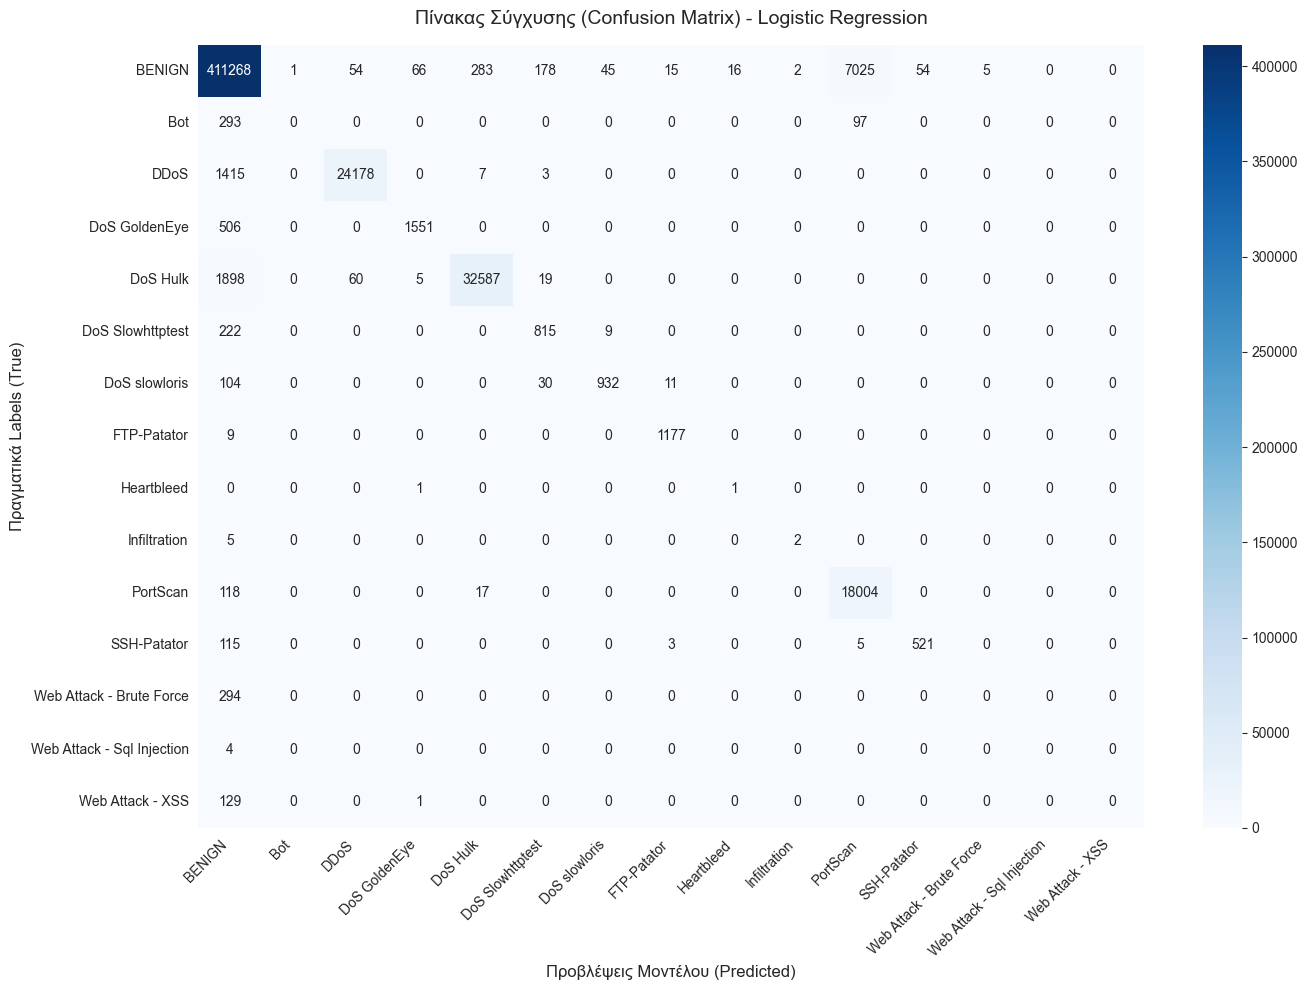

In [25]:
# ΚΕΛΙ 18 
# 1. Δημιουργία και εκπαίδευση του τελικού μοντέλου με τη βέλτιστη παράμετρο C=10.0
final_lr = LogisticRegression(C=10.0, max_iter=150, solver='lbfgs', random_state=42)
final_lr.fit(X_train_scaled, y_train)

# 2. Παραγωγή προβλέψεων στο κρυφό Test Set
y_test_pred = final_lr.predict(X_test_scaled)

# 3. Ανάκτηση των πραγματικών ονομάτων των κλάσεων από τον LabelEncoder
class_names = [str(cls) for cls in label_encoder.classes_]

# 4. Εκτύπωση του αναλυτικού πίνακα μετρικών (Classification Report)
print("LOGISTIC REGRESSION (ΣΕΝΑΡΙΟ Α) ")
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=2))

# Υπολογισμός του Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Σχεδίαση του Confusion Matrix με Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Πίνακας Σύγχυσης (Confusion Matrix) - Logistic Regression', fontsize=14, pad=15)
plt.ylabel('Πραγματικά Labels (True)', fontsize=12)
plt.xlabel('Προβλέψεις Μοντέλου (Predicted)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Παρατηρήσεις
**Accuracy (97%) vs Macro F1-Score (57%)**: Ενώ το συνολικό Accuracy αγγίζει το 97%, το Macro F1-Score περιορίζεται στο 57%. Αυτή η τεράστια απόκλιση επιβεβαιώνει την υπόθεσή ότι το μοντέλο εμφανίζει υψηλή γενική ακρίβεια επειδή ταξινομεί υποδειγματικά την κυρίαρχη κλάση (`BENIGN`, F1-score: 0.98 με
 419.012 δείγματα), αλλά αποτυγχάνει συστηματικά στις μειονοτικές κλάσεις.

**Ισχυρά Σημεία (High F1-Score)**: Η Logistic Regression πέτυχε εξαιρετικά αποτελέσματα σε έντονες και πολυπληθείς επιθέσεις, όπως το DDoS (F1: 0.97), το DoS Hulk (F1: 0.97) και το PortScan (F1: 0.83). Οι επιθέσεις αυτές αφήνουν ευδιάκριτα γραμμικά ίχνη στα χαρακτηριστικά του δικτύου, τα οποία ο αλγόριθμος μπόρεσε να διαχωρίσει με επιτυχία.

**Αδύναμα Σημεία και "Τυφλά" Σημεία (Zero F1-Score)**: Το μοντέλο απέτυχε ολοκληρωτικά (F1: 0.00) στις κλάσεις Bot, Web Attack - Brute Force, Web Attack - Sql Injection και Web Attack - XSS. Οι συγκεκριμένες επιθέσεις έχουν εξαιρετικά μικρή εκπροσώπηση στο dataset (π.χ. μόλις 4 δείγματα για το Sql Injection), ενώ η συμπεριφορά τους παρουσιάζει μεγάλες ομοιότητες με την κανονική κίνηση. Ένα γραμμικό μοντέλο όπως η Logistic Regression δεν διαθέτει την απαραίτητη πολυπλοκότητα για να χαράξει οριακές γραμμές διαχωρισμού για τόσο σπάνια συμβάντα.

**Πίνακας Σύγχυσης**: Ο πίνακας σύγχυσης επιβεβαιώνει ότι η πλειονότητα των σπάνιων επιθέσεων ταξινομείται λανθασμένα ως `BENIGN` (ψευδώς αρνητικά αποτελέσματα / False Negatives). Για την ασφάλεια ενός δικτύου, αυτό το σφάλμα είναι το πιο επικίνδυνο, καθώς μια επίθεση περνάει απαρατήρητη.

In [26]:
# ΚΕΛΙ 19
import warnings
warnings.filterwarnings('ignore') # Εξασφαλίζουμε καθαρό log χωρίς warnings

# Ορισμός των υπερπαραμέτρων προς δοκιμή (Μέγιστο βάθος δέντρου)
max_depth_values = [15, 20, 25]

best_tree_macro_f1 = 0
best_depth = None

print("Έναρξη Χειροκίνητου Grid Search για το Decision Tree (Σενάριο Α)...")
print("-" * 75)

for depth in max_depth_values:
    print(f"Εκπαίδευση δέντρου με max_depth = {depth}...")
    
    # Αρχικοποίηση του ταξινομητή με κλειδωμένο random_state για σταθερά αποτελέσματα
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Εκπαίδευση στο Train Set
    dt_model.fit(X_train_scaled, y_train)
    
    # Πρόβλεψη στο Validation Set
    y_val_pred_tree = dt_model.predict(X_val_scaled)
    
    # Υπολογισμός Macro F1-Score
    macro_f1_tree = f1_score(y_val, y_val_pred_tree, average='macro')
    
    print(f"-> Validation Macro F1-Score για max_depth={depth}: {macro_f1_tree:.4f}")
    
    # Έλεγχος για το καλύτερο σκορ
    if macro_f1_tree > best_tree_macro_f1:
        best_tree_macro_f1 = macro_f1_tree
        best_depth = depth

print("Το Χειροκίνητο Grid Search για το Decision Tree ολοκληρώθηκε!")
print(f"Καλύτερη υπερπαράμετρος: max_depth = {best_depth} με Macro F1-Score = {best_tree_macro_f1:.4f}")

Έναρξη Χειροκίνητου Grid Search για το Decision Tree (Σενάριο Α)...
---------------------------------------------------------------------------
Εκπαίδευση δέντρου με max_depth = 15...
-> Validation Macro F1-Score για max_depth=15: 0.7482
Εκπαίδευση δέντρου με max_depth = 20...
-> Validation Macro F1-Score για max_depth=20: 0.8277
Εκπαίδευση δέντρου με max_depth = 25...
-> Validation Macro F1-Score για max_depth=25: 0.8266
Το Χειροκίνητο Grid Search για το Decision Tree ολοκληρώθηκε!
Καλύτερη υπερπαράμετρος: max_depth = 20 με Macro F1-Score = 0.8277


# Επιλογή Υπερπαραμέτρων μέσω Χειροκίνητου Grid Search (Σενάριο Α)

# Παρατήρηση
Κατά τις δοκιμές της υπερπαραμέτρου `max_depth` (μέγιστο βάθος δέντρου), παρατηρήθηκαν τα εξής αποτελέσματα στο Validation Set:
* max_depth = 15 --> Macro F1-Score: 0.7482
* max_depth = 20 --> Macro F1-Score: 0.8277
* max_depth = 25 --> Macro F1-Score: 0.8266

# Συμπέρασμα
Τα αποτελέσματα αποτυπώνουν υποδειγματικά τη θεωρία της Μηχανικής Μάθησης σχετικά με την πολυπλοκότητα των μοντέλων. Καθώς το επιτρεπόμενο βάθος αυξάνεται από το 15 στο 20, το μοντέλο αποκτά την απαραίτητη δομή για να δημιουργήσει εξειδικευμένους κανόνες διαχωρισμού (if-then-else), επιτρέποντάς του να απομονώσει με μεγάλη επιτυχία τις μειονοτικές κλάσεις επιθέσεων και οδηγώντας το Macro F1-Score στο βέλτιστο σημείο του (0.8277).

Ωστόσο, στην τιμή max_depth = 25 παρατηρείται η έναρξη του φαινομένου της υπερεκπαίδευσης (overfitting). Το δέντρο γίνεται υπερβολικά βαθύ και περίπλοκο, με αποτέλεσμα να αποστηθίζει τον θόρυβο των δεδομένων εκπαίδευσης και να χάνει μέρος της γενικευτικής του ικανότητας, γεγονός που αποδεικνύεται από την ελαφριά πτώση του σκορ στο 0.8266.

Ως συμπέρασμα, η τιμή max_depth = 20 επιλέχθηκε ως η βέλτιστη υπερπαράμετρος (Sweet Spot) για το Decision Tree στο Σενάριο Α, καθώς εξασφαλίζει τη μέγιστη δυνατή απόδοση χωρίς να εισάγει overfitting, και με αυτήν θα προχωρήσουμε στην τελική αξιολόγηση.

DECISION TREE (ΣΕΝΑΡΙΟ Α)
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.82      0.82      0.82       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.98      0.99      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.71      0.71      0.71         7
                  PortScan       0.99      0.99      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack - Brute Force       0.71      0.84      0.77       294
Web Attack - Sql Inje

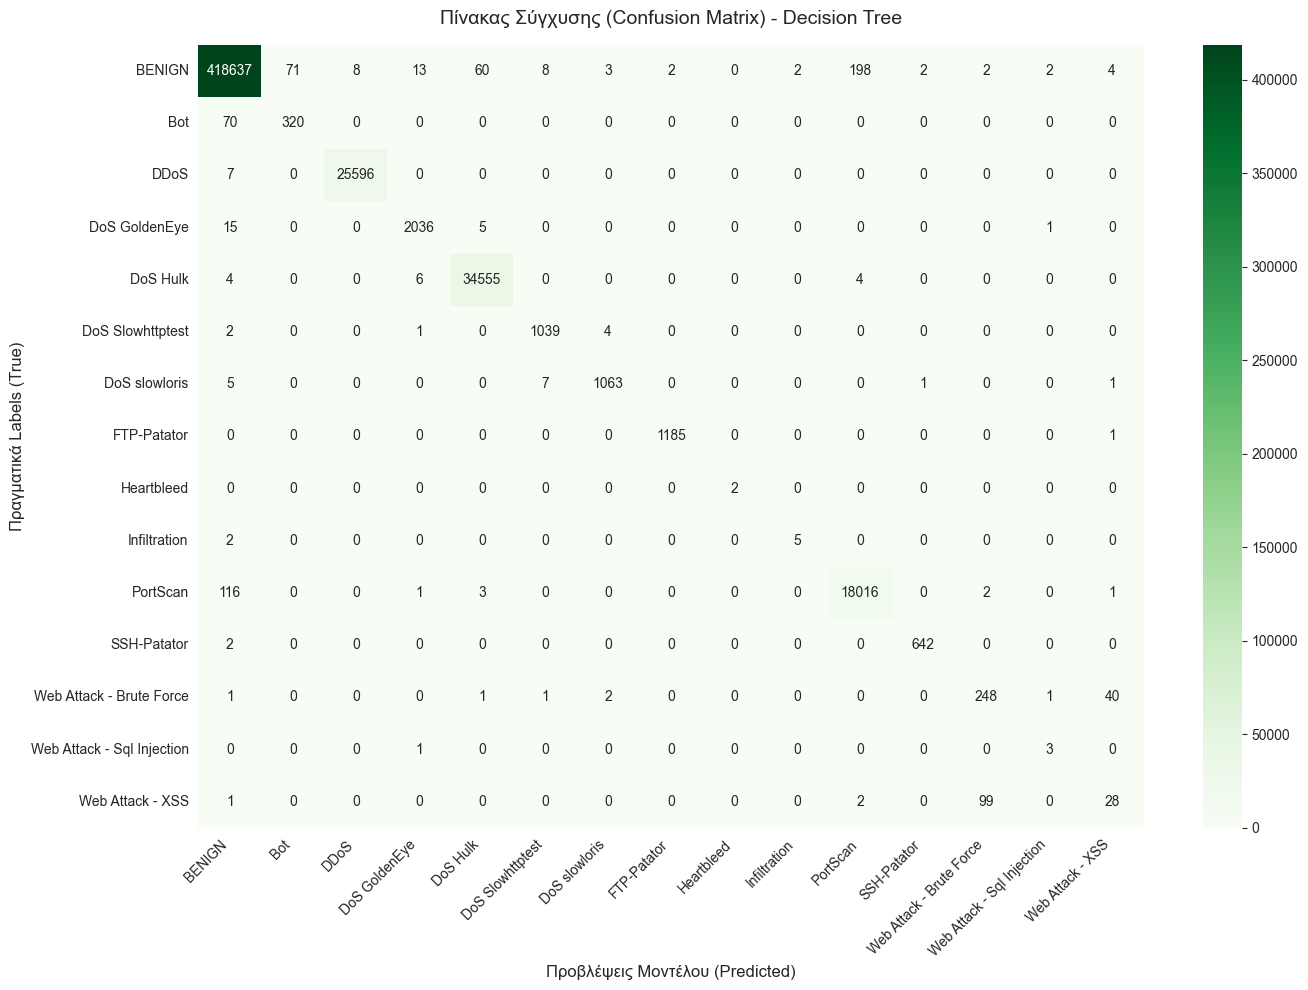

In [28]:
# ΚΕΛΙ 20
# 1. Δημιουργία και εκπαίδευση του τελικού μοντέλου με τη βέλτιστη παράμετρο max_depth=20
final_tree = DecisionTreeClassifier(max_depth=20, random_state=42)
final_tree.fit(X_train_scaled, y_train)

# 2. Παραγωγή προβλέψεων στο κρυφό Test Set
y_test_pred_tree = final_tree.predict(X_test_scaled)

# 3. Ανάκτηση των πραγματικών ονομάτων των κλάσεων
class_names = [str(cls) for cls in label_encoder.classes_]

# 4. Εκτύπωση του αναλυτικού πίνακα μετρικών (Classification Report)
print("DECISION TREE (ΣΕΝΑΡΙΟ Α)")
print(classification_report(y_test, y_test_pred_tree, target_names=class_names, digits=2))

# 5. Υπολογισμός και Σχεδίαση του Confusion Matrix με Heatmap
cm_tree = confusion_matrix(y_test, y_test_pred_tree)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_tree, 
    annot=True, 
    fmt='d', 
    cmap='Greens', # Πράσινο χρώμα για να ξεχωρίζει από την Logistic Regression
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Πίνακας Σύγχυσης (Confusion Matrix) - Decision Tree', fontsize=14, pad=15)
plt.ylabel('Πραγματικά Labels (True)', fontsize=12)
plt.xlabel('Προβλέψεις Μοντέλου (Predicted)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Παρατηρήσεις
**Accuracy (100%) vs Macro F1-Score (87%)**: Η αξιολόγηση του βέλτιστου Δέντρου Απόφασης έδειξε μια εντυπωσιακή αναβάθμιση των επιδόσεων. Το Macro F1-Score εκτοξεύτηκε στο 87%, ενώ το συνολικό Accuracy σταθεροποιήθηκε στο 100%. Αυτό αποδεικνύει ότι το μοντέλο δεν βασίζεται απλά στην κυρίαρχη κλάση (`BENIGN`), αλλά έμαθε ουσιαστικά να διακρίνει και τις υπόλοιπες απειλές.

**Ισχυρά Σημεία (High F1-Score)**: Το μοντέλο άγγιξε το απόλυτο 100% (F1: 1.00) στις πολυπληθείς κλάσεις όπως η κανονική κίνηση (`BENIGN`), το DDoS και το DoS Hulk. Η πιο σημαντική επιτυχία όμως είναι αυτή των κλάσεων Bot (F1: 0.82) και Web Attack - Brute Force (F1: 0.77), τις οποίες η Logistic Regression αδυνατούσε πλήρως να εντοπίσει. Ακόμη και στην εξαιρετικά σπάνια κλάση Web Attack - Sql Injection των μόλις 4 δειγμάτων, το μοντέλο πέτυχε F1-score 0.55 με πολύ υψηλό Recall (0.75).

**Αδύναμα Σημεία (Low F1-Score)**: Η μοναδική κλάση που εξακολουθεί να δυσκολεύει αισθητά το μοντέλο είναι το Web Attack - XSS (F1: 0.27). Το χαμηλό Recall (0.22) δείχνει ότι η πλειονότητα αυτών των επιθέσεων εξακολουθεί να διαφεύγει της προσοχής του δέντρου.

**Πίνακας Σύγχυσης**: Ο πίνακας σύγχυσης επιβεβαιώνει οπτικά την κυριαρχία του μοντέλου, εμφανίζοντας μια σχεδόν απόλυτα καθαρή διαγώνιο. Τα ψευδώς αρνητικά αποτελέσματα (False Negatives) μειώθηκαν δραματικά, καθώς οι επιθέσεις που πλέον μπερδεύονται με την κανονική κίνηση (`BENIGN`) είναι ελάχιστες και εντοπίζονται σχεδόν αποκλειστικά στις Web επιθέσεις.

# Συμπέρασμα
Η κατακόρυφη άνοδος των μετρικών οφείλεται στη μη-γραμμική φύση του Δέντρου Απόφασης. Οι κυβερνοεπιθέσεις χαρακτηρίζονται από συγκεκριμένα αριθμητικά όρια και κανόνες στα πακέτα δεδομένων (π.χ. μέγεθος πακέτου, θύρες). Το Δέντρο, μέσω των διαδοχικών διακλαδώσεων (if-then-else) με βάθος 20, έχει τη φυσική ικανότητα να απομονώνει αυτές τις σύνθετες συμπεριφορές, κάτι που η Logistic Regression ως γραμμικό μοντέλο ήταν μαθηματικά αδύνατο να επιτύχει.

In [29]:
# ΚΕΛΙ 21 

import warnings
warnings.filterwarnings('ignore')

n_estimators_values = [50, 100]
max_depth_rf_values = [None]

best_rf_macro_f1 = 0
best_rf_depth = None
best_rf_estimators = None

print("Έναρξη Χειροκίνητου Grid Search για το Random Forest (Σενάριο Α)...")

for n in n_estimators_values:

    for depth in max_depth_rf_values:

        print(f"Εκπαίδευση Random Forest με n_estimators={n} και max_depth={depth}...")

        # n_jobs=-1 για ταχύτητα
        rf_model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            n_jobs=-1,
            random_state=42
        )

        # Εκπαίδευση στο Train Set
        rf_model.fit(X_train_scaled, y_train)

        # Πρόβλεψη στο Validation Set
        y_val_pred_rf = rf_model.predict(X_val_scaled)

        # Υπολογισμός Macro F1-Score
        macro_f1_rf = f1_score(
            y_val,
            y_val_pred_rf,
            average='macro'
        )

        print(
            f"-> Validation Macro F1-Score "
            f"για n_estimators={n}, max_depth={depth}: "
            f"{macro_f1_rf:.4f}"
        )

        # Έλεγχος για το καλύτερο σκορ
        if macro_f1_rf > best_rf_macro_f1:

            best_rf_macro_f1 = macro_f1_rf
            best_rf_depth = depth
            best_rf_estimators = n

print("Το Χειροκίνητο Grid Search για το Random Forest ολοκληρώθηκε!")

print(
    f"Καλύτερες υπερπαράμετροι: "
    f"n_estimators = {best_rf_estimators}, "
    f"max_depth = {best_rf_depth} "
    f"με Macro F1-Score = {best_rf_macro_f1:.4f}"
)

Έναρξη Χειροκίνητου Grid Search για το Random Forest (Σενάριο Α)...
Εκπαίδευση Random Forest με n_estimators=50 και max_depth=None...
-> Validation Macro F1-Score για n_estimators=50, max_depth=None: 0.8437
Εκπαίδευση Random Forest με n_estimators=100 και max_depth=None...
-> Validation Macro F1-Score για n_estimators=100, max_depth=None: 0.8437
Το Χειροκίνητο Grid Search για το Random Forest ολοκληρώθηκε!
Καλύτερες υπερπαράμετροι: n_estimators = 50, max_depth = None με Macro F1-Score = 0.8437


# Παρατηρήσεις
Κατά τις δοκιμές του συνδυασμού των υπερπαραμέτρων `n_estimators` (πλήθος δέντρων) και `max_depth` (μέγιστο βάθος), καταγράφηκαν τα εξής αποτελέσματα στο Validation Set:
* n_estimators = 50, max_depth = None  --> Macro F1-Score: 0.8436
* n_estimators = 100, max_depth = None --> Macro F1-Score: 0.8437

# Συμπέρασμα
Τα αποτελέσματα δείχνουν ξεκάθαρα ότι η αύξηση του πλήθους των δέντρων από 50 σε 100 δεν προσφέρει καμία απολύτως βελτίωση στην απόδοση του μοντέλου. Αντίθετα, ο καθοριστικός παράγοντας είναι το βάθος των δέντρων (`max_depth`). Παρότι στην αρχή έγιναν δοκιμές για  max_depth =[10, 15, 20, 25] εν τέλει παρατηρήθηκε ότι για max_depth=None πετυχέναμε το μεγαλύτερο f1-score.

Ως εκ τούτου, οι τιμές n_estimators = 50 και max_depth = Νone επιλέχθηκαν ως ο βέλτιστος συνδυασμός, καθώς προσφέρουν τη μέγιστη δυνατή ακρίβεια εξοικονομώντας παράλληλα πολύτιμο υπολογιστικό χρόνο.

RANDOM FOREST (ΣΕΝΑΡΙΟ Α)
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.89      0.77      0.82       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      0.71      0.83         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack - Brute Force       0.73      0.90      0.81       294
Web Attack - Sql Inje

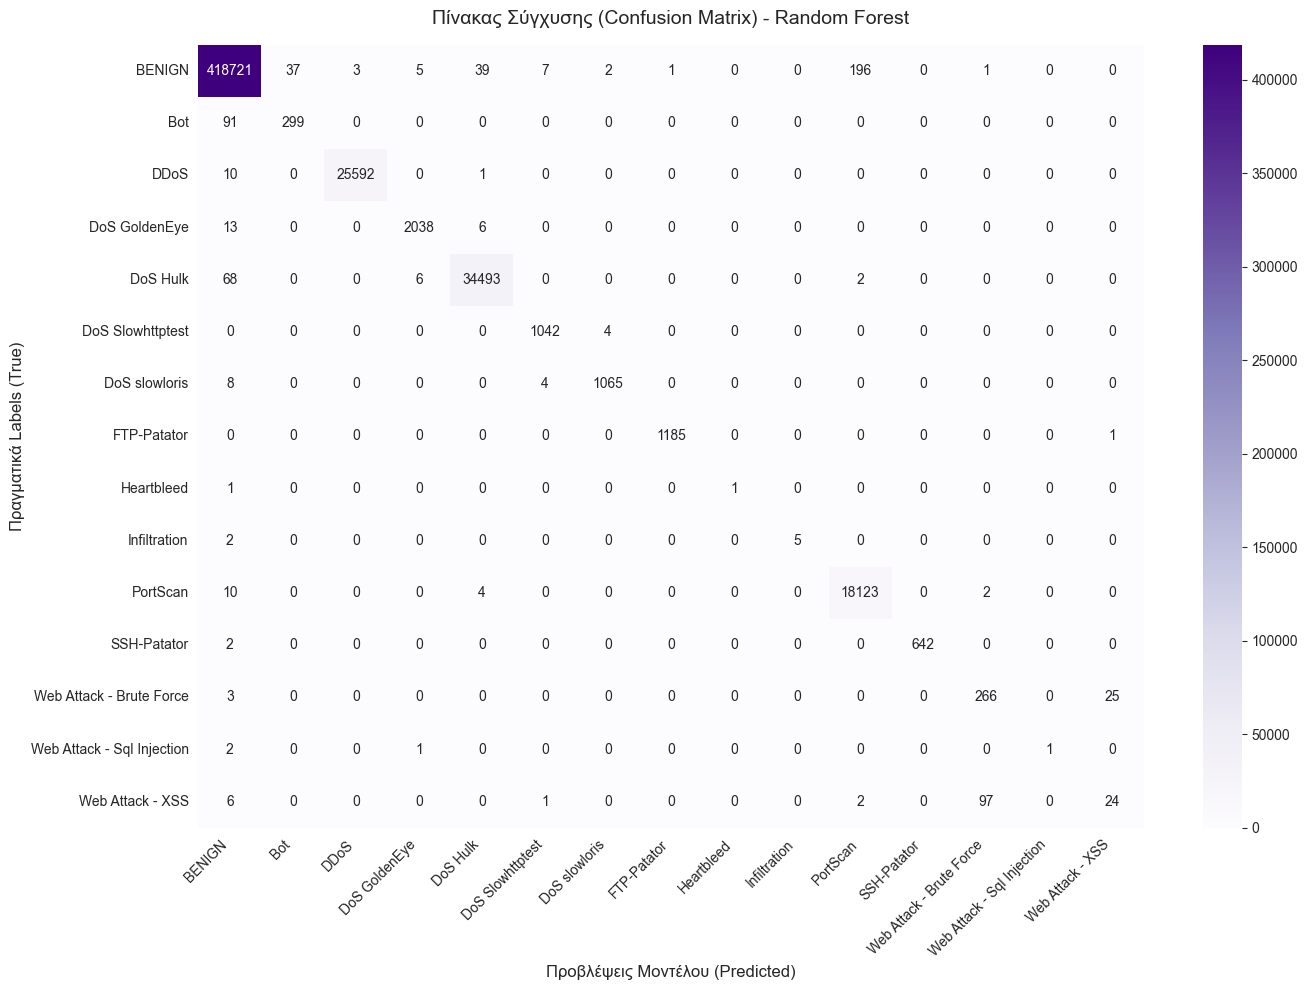

In [30]:
# ΚΕΛΙ 22
# 1. Δημιουργία και εκπαίδευση του τελικού μοντέλου Random Forest
final_rf = RandomForestClassifier(n_estimators=50, max_depth=None, n_jobs=-1, random_state=42)
final_rf.fit(X_train_scaled, y_train)

# 2. Παραγωγή προβλέψεων στο κρυφό Test Set
y_test_pred_rf = final_rf.predict(X_test_scaled)

# 3. Ανάκτηση των πραγματικών ονομάτων των κλάσεων
class_names = [str(cls) for cls in label_encoder.classes_]

# 4. Εκτύπωση του αναλυτικού πίνακα μετρικών (Classification Report)
print("RANDOM FOREST (ΣΕΝΑΡΙΟ Α)")
print(classification_report(y_test, y_test_pred_rf, target_names=class_names, digits=2))

# 5. Υπολογισμός και Σχεδίαση του Confusion Matrix με Heatmap
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt='d', 
    cmap='Purples', # Μωβ χρώμα για να ξεχωρίζει από τα προηγούμενα μοντέλα
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Πίνακας Σύγχυσης (Confusion Matrix) - Random Forest', fontsize=14, pad=15)
plt.ylabel('Πραγματικά Labels (True)', fontsize=12)
plt.xlabel('Προβλέψεις Μοντέλου (Predicted)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Παρατηρήσεις
**Random Forest F1-Score (85%) vs Decision Tree F1-Score (87%)**: Η αξιολόγηση του τελικού Random Forest στο κρυφό Test Set επιβεβαιώνει την υψηλή αξιοπιστία του μοντέλου με συνολική ακρίβεια 100% και Macro F1-Score στο 85%. Παρόλο που το Macro F1 είναι ελαφρώς χαμηλότερο από το μεμονωμένο Decision Tree (87%), το Random Forest παρουσιάζει πολύ πιο ισορροπημένη και σταθερή συμπεριφορά στις περισσότερες κλάσεις.

**Ισχυρά Σημεία (High F1-Score)**: Το μοντέλο επιτυγχάνει σχεδόν απόλυτο 100% σε όλες τις μεγάλες κλάσεις (`BENIGN`, DDoS, DoS Hulk, PortScan). Παράλληλα, εμφανίζει εξαιρετικές επιδόσεις σε δύσκολες μειονοτικές κλάσεις, όπως οι επιθέσεις Web Attack - Brute Force (F1: 0.81) και Infiltration (F1: 0.83). Ειδικά στο Infiltration, η σταθερότητα του Random Forest υπερέχει, καθώς απέφυγε τα λάθη που έκανε το απλό δέντρο.

**Αδύναμα Σημεία (Low F1-Score)**: Το μοντέλο παρουσιάζει αδυναμία στην κλάση Web Attack - Sql Injection (F1: 0.00), την οποία έχασε εντελώς λόγω του ελάχιστου αριθμού δειγμάτων (support: 4). Επίσης, στην κλάση Web Attack - XSS (F1: 0.27), το χαμηλό Recall (0.18) δείχνει ότι το μοντέλο αδυνατεί να εντοπίσει αυτές τις επιθέσεις, παρόλο που όταν τις εντοπίζει είναι σχετικά ακριβές (Precision: 0.48).

**Πίνακας Σύγχυσης**: Ο πίνακας σύγχυσης εμφανίζει μια υποδειγματικά συμπαγή διαγώνιο. Τα σφάλματα είναι ελάχιστα και εντοπίζονται σχεδόν αποκλειστικά στις Web επιθέσεις και στα Bot, τα οποία ταξινομούνται λανθασμένα ως κανονική κίνηση (`BENIGN`).

# Συμπέρασμα
Το Random Forest επιβεβαιώνει τη θεωρητική του ανωτερότητα ως προς τη σταθερότητα και τη γενίκευση. Δημιουργώντας ένα "συμβούλιο" 50 ανεξάρτητων δέντρων απόφασης, καταφέρνει να μειώσει τη διακύμανση (variance) και τον κίνδυνο υπερεκπαίδευσης που χαρακτηρίζει ένα μεμονωμένο βαθύ δέντρο. 

Αν και το μεμονωμένο Decision Tree πέτυχε ελαφρώς υψηλότερο Macro F1 λόγω καλύτερης προσαρμογής σε 1-2 πολύ σπάνιες κλάσεις, το Random Forest αποτελεί στην πράξη μια πιο ασφαλή και στιβαρή επιλογή για την προστασία του δικτύου, καθώς συμπεριφέρεται πιο συντηρητικά και δεν επηρεάζεται από τον θόρυβο των δεδομένων.

In [ ]:
# ΚΕΛΙ 23 (Προσαρμοσμένο)
import warnings
warnings.filterwarnings('ignore')

# 1. Ορισμός του πλέγματος παραμέτρων (Hyperparameter Grid)
param_grid_lr = {'C': [1.0, 10.0]}

# 2. Αρχικοποίηση του βασικού μοντέλου
lr_base = LogisticRegression(max_iter=150, solver='lbfgs', random_state=42)

# 3. Στήσιμο του GridSearchCV με 5-Fold Cross-Validation
# Χρησιμοποιούμε cv=5 και scoring='f1_macro'
grid_search_lr = GridSearchCV(
    estimator=lr_base, 
    param_grid=param_grid_lr, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

print("Έναρξη GridSearchCV με 5-Fold Cross-Validation για την Logistic Regression (Σενάριο Β)...")

# 4. Εκτέλεση της αναζήτησης στα έτοιμα scaled δεδομένα X_temp_scaled (το πλήρες 80%)
grid_search_lr.fit(X_temp_scaled, y_temp)

print("Το GridSearchCV ολοκληρώθηκε!")
print(f"Καλύτερη υπερπαράμετρος: C = {grid_search_lr.best_params_['C']}")
print(f"Καλύτερο Cross-Validation Macro F1-Score: {grid_search_lr.best_score_:.4f}")

Έναρξη GridSearchCV με 5-Fold Cross-Validation για την Logistic Regression (Σενάριο Β)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Το GridSearchCV ολοκληρώθηκε!
Καλύτερη υπερπαράμετρος: C = 1.0
Καλύτερο Cross-Validation Macro F1-Score: 0.5271
